<div style="font-family: 'Helvetica Neue', Arial, sans-serif; background:#fff; padding: 36px 40px; border-radius: 8px; margin-bottom: 4px; position:relative; overflow:hidden; border: 1.5px solid #e8e8e8;">

  <div style="font-size:130px; font-weight:900; color:rgba(0,0,0,0.04); position:absolute; top:-20px; right:30px; line-height:1; letter-spacing:-0.05em;">01</div>

  <div style="font-size:10px; color:#00D563; letter-spacing:0.25em; text-transform:uppercase; margin-bottom:16px;">NOVA IMS &middot; 2025/2026</div>
  <div style="font-size:36px; font-weight:800; color:#111; letter-spacing:-0.02em; line-height:1.1; margin-bottom:6px;">Mining Sentiment <span style="color:#00D563;">from Financial Tweets.</span></div>
  <div style="font-size:12px; color:#00D563; font-weight:500; margin-bottom:24px;">Notebook 1 &mdash; Experiments &amp; Evaluation</div>

  <div style="display:flex; gap:48px;">
    <div>
      <div style="font-size:9px; color:#00D563; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:6px;">Group 33</div>
      <div style="font-size:11px; color:#555; line-height:1.9;">Alexandra Varela, 20250514<br>Francisca Fernandes, 20250406<br>Mariana Melo, 20250414<br>Tiago Antunes, 20250357</div>
    </div>
    <div>
      <div style="font-size:9px; color:#00D563; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:6px;">Course</div>
      <div style="font-size:11px; color:#555; line-height:1.9;">Text Mining<br>MSc Data Science &amp; Advanced Analytics<br>NOVA Information Management School</div>
    </div>
  </div>
</div>

# 0.1. Table of Contents

# 0.2. Methodology

The results in this notebook do not come from ad-hoc code written inline. They are produced by a set of shared modules and standalone scripts that enforce a consistent protocol across all experiments.

**`src/preprocessing.py`** cleans and tokenizes every tweet before any model sees it (URL/mention removal, NFKD normalization, TweetTokenizer, stopword filtering with negation preservation, lemmatization). **`src/features.py`** builds all feature representations - BoW, TF-IDF variants, Word2Vec, GloVe-Twitter, BERT/SBERT embeddings, and 14 hand-crafted financial features. **`src/evaluation.py`** runs every classical model through the same 5-fold stratified cross-validation (`StratifiedKFold`, seed 42) and returns a standardized result dict; all rows in the comparison tables come from this function. **`src/utils.py`** fixes the global seed (42) across Python, NumPy, and PyTorch so every run is reproducible. **`src/agent.py`** implements the agentic orchestration system (Phase 8).

Transformer fine-tuning results (Phase 7) are produced outside the notebook by `scripts/run_transformer_cv_v2.py`, launched in batch via `scripts/run_experiments_v2.ps1`. Each run writes a JSON result card to `results/tables/` and probability arrays to `results/predictions/`; the notebook loads these files rather than re-running training. Ensemble results are produced by `scripts/compare_and_ensemble.py`, which soft-averages the probability arrays of the top models.

# 0.3. Setup & Imports

In [17]:
# Core
import os
import re
import sys
import json
import string
import unicodedata
import warnings
from collections import Counter

warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

# Data
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
from matplotlib_venn import venn3

# NLP
import nltk
import emoji
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.tokenize import TweetTokenizer
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('vader_lexicon', quiet=True)

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold

# Preprocessing (inline functions loaded in Section 3)
from src.preprocessing import (
    clean_twitter_noise, normalize_text,
    remove_stopwords, lemmatize_tokens,
    stem_tokens, tokenize_tweet, full_pipeline,
    KEEP_NEGATIONS,
)

# Aesthetics
PALETTE   = {0: '#E8534A', 1: '#00D563', 2: '#5B9BD5'}   # Bear / Bull / Neutral
LABEL_MAP = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
COLORS    = [PALETTE[k] for k in sorted(PALETTE)]

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

print('Libraries loaded')

Libraries loaded


---

# 1. Data Exploration

This section performs a thorough exploratory analysis of the financial tweet sentiment dataset. The goal is to understand the structure, distribution and linguistic characteristics of the corpus before any modelling decisions are made.

**Labels:** `0 = Bearish`  `1 = Bullish` `2 = Neutral`

## 1.1. Data Loading

We load both splits immediately so every subsequent section can reference train and test in parallel. Mapping integer labels to names once here keeps all downstream prints and plots consistent without repeated inline conversions.

In [18]:
train = pd.read_csv('data/raw/train.csv')
test  = pd.read_csv('data/raw/test.csv')

# Map numeric labels to names (keep original column)
train['sentiment'] = train['label'].map(LABEL_MAP)

print(f'Train : {train.shape[0]:,} rows x {train.shape[1]} cols')
print(f'Test  : {test.shape[0]:,}  rows x {test.shape[1]} cols')
train.head()

Train : 9,543 rows x 3 cols
Test  : 2,388  rows x 2 cols


,text,label,sentiment
0,$BYND - JPMorgan reels in expectations on Beyo...,0,Bearish
1,$CCL $RCL - Nomura points to bookings weakness...,0,Bearish
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,Bearish
3,$ESS: BTIG Research cuts to Neutral https://t....,0,Bearish
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0,Bearish


## 1.2. Schema & Basic Quality Check

A quality gate before any analysis. Missing values would force an imputation decision; duplicates would silently inflate metric estimates; train/test overlap would be a data leakage risk.

In [19]:
print('-> dtypes & nulls (train)')
print(train.dtypes)
print()
print('Missing values:')
print(train.isnull().sum())
print()
print('Duplicate tweets in train:', train['text'].duplicated().sum())
print('Duplicate tweets in test :', test['text'].duplicated().sum())
print()
print('Train/Test overlap (exact text match):',
      train['text'].isin(test['text']).sum())

-> dtypes & nulls (train)
text         object
label         int64
sentiment    object
dtype: object

Missing values:
text         0
label        0
sentiment    0
dtype: int64

Duplicate tweets in train: 0
Duplicate tweets in test : 0

Train/Test overlap (exact text match): 0


**Findings:** The dataset passes the basic schema-level checks: no missing values, no exact duplicate tweets and no exact train/test text overlap. Deeper linguistic and near-duplicate audits are performed later in the EDA. This means no imputation or deduplication step is needed and our validation estimates are not contaminated by leakage. We can move straight to analysis.

## 1.3. Class Distribution

The class proportions determine which evaluation metric is meaningful, whether the loss function needs weighting and how to construct validation folds. Knowing the imbalance ratio upfront prevents a common mistake: reporting raw accuracy on an imbalanced dataset and mistaking it for a good result.

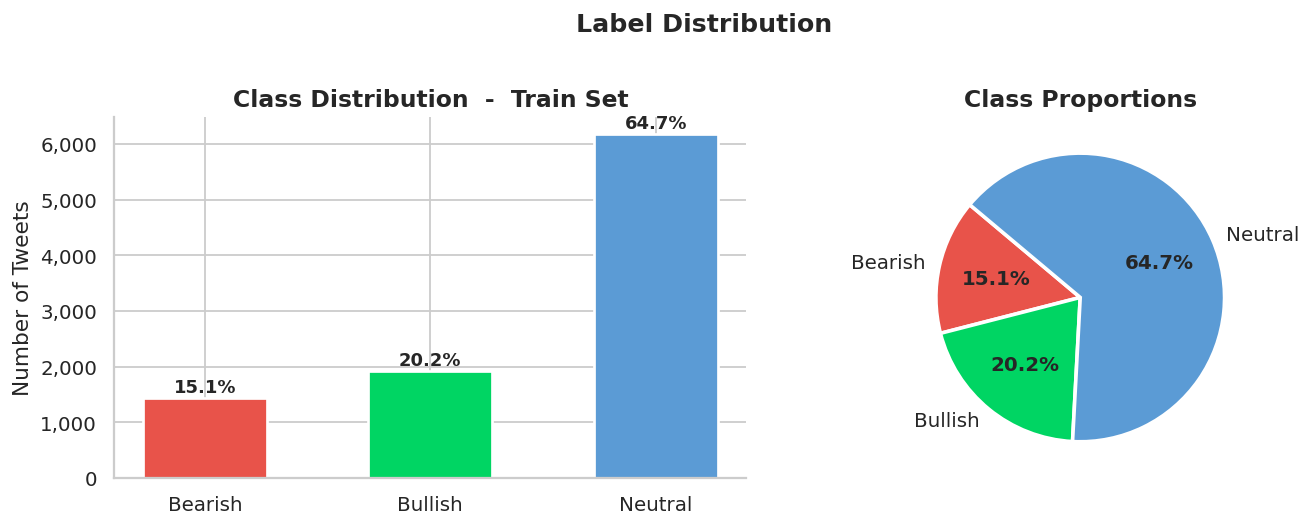

       count    pct
label              
0       1442  15.11
1       1923  20.15
2       6178  64.74


In [20]:
counts = train['label'].value_counts().sort_index()
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(
    [LABEL_MAP[i] for i in counts.index],
    counts.values,
    color=COLORS, edgecolor='white', linewidth=1.5, width=0.55
)
for bar, pct in zip(bars, pcts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
axes[0].set_title('Class Distribution  -  Train Set')
axes[0].set_ylabel('Number of Tweets')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts, labels=[LABEL_MAP[i] for i in counts.index],
    colors=COLORS, autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Class Proportions')

plt.suptitle('Label Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(counts.rename('count').to_frame().assign(pct=pcts.round(2)))

**Findings:** Neutral accounts for 64.7% of training samples (more than Bearish and Bullish combined). The Neutral/Bearish ratio is 4.28:1. A classifier that always predicts Neutral achieves 64.7% accuracy without learning anything. Consequences for modelling: (1) we use **macro-F1** as the primary metric throughout; (2) training will use class-weighted loss; (3) cross-validation folds must be stratified to preserve the imbalance in every split.

## 1.4. Tweet Length Analysis

Tweet length matters for two reasons: it sets the `max_length` parameter for transformer tokenisers (padding and truncation affect both speed and accuracy) and systematic length differences between classes could become a spurious feature that a model overfits. We inspect both character and word count across classes and both splits.

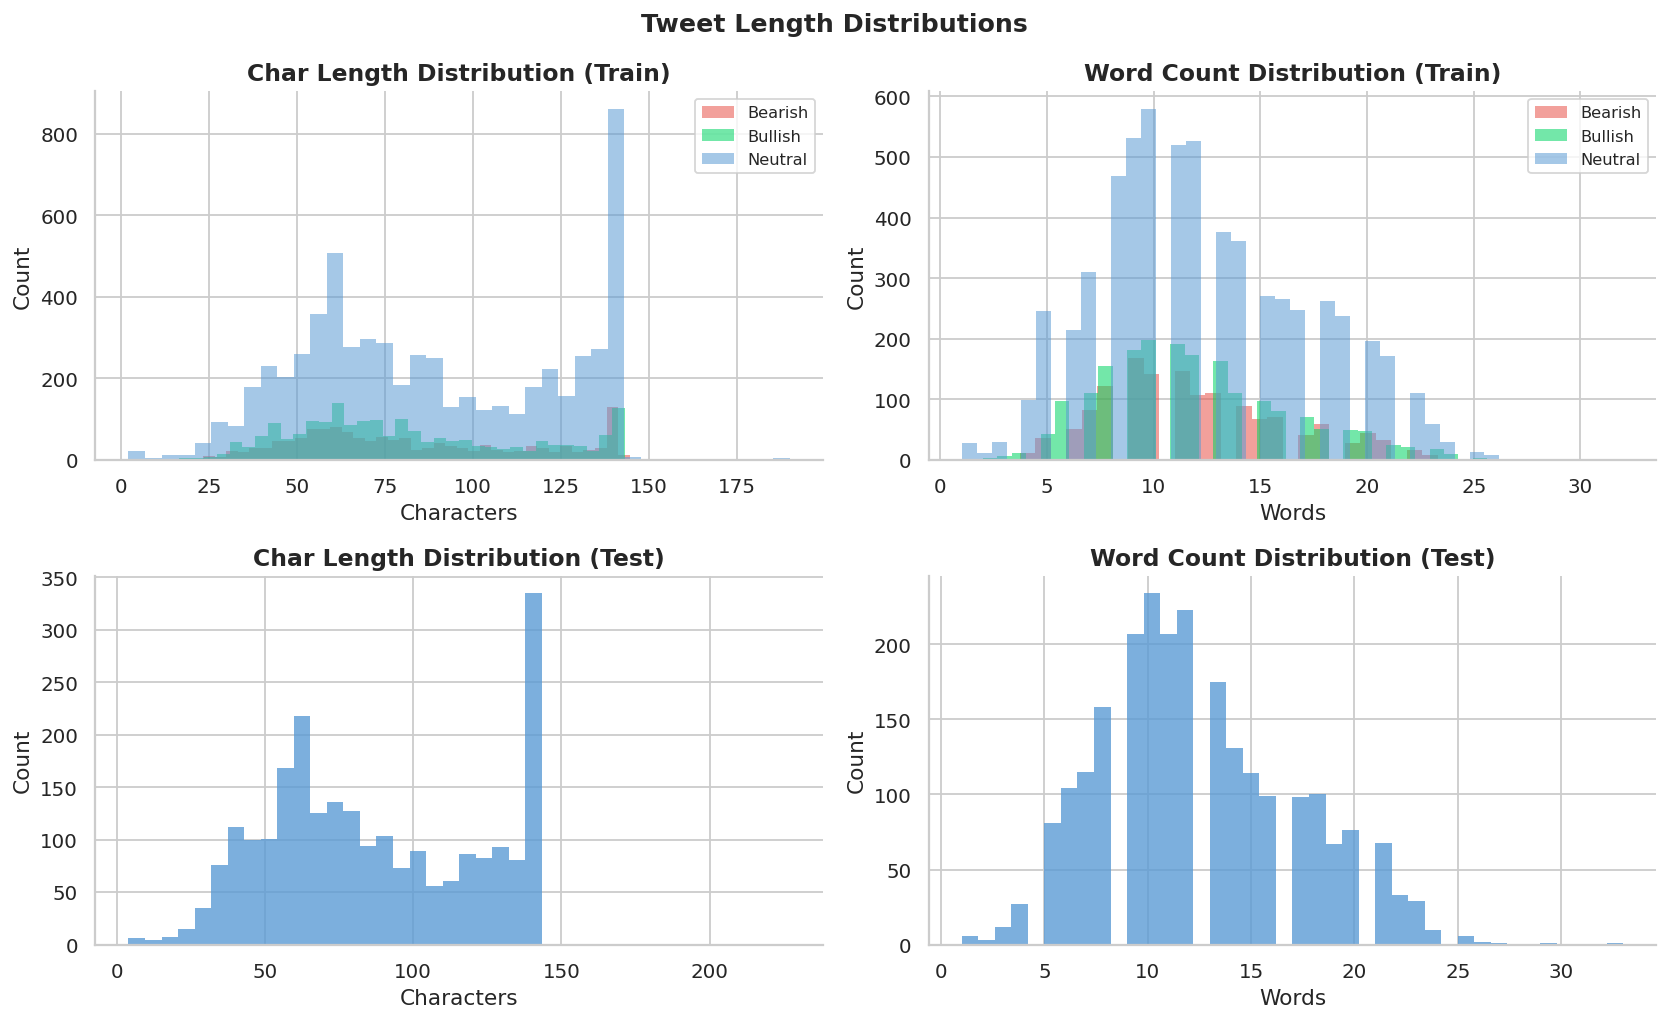

Train length stats by class:
          char_len              word_count            
              mean median   std       mean median  std
sentiment                                             
Bearish       83.3   75.5  33.0       12.0   11.0  4.3
Bullish       80.4   74.0  32.3       11.9   11.0  4.3
Neutral       88.1   82.0  36.2       12.3   12.0  4.8


In [21]:
train['char_len']  = train['text'].str.len()
train['word_count'] = train['text'].str.split().str.len()
test['char_len']   = test['text'].str.len()
test['word_count'] = test['text'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, col, title, xlabel in zip(
    axes.flat,
    ['char_len', 'word_count', 'char_len', 'word_count'],
    ['Char Length Distribution (Train)', 'Word Count Distribution (Train)',
     'Char Length Distribution (Test)',  'Word Count Distribution (Test)'],
    ['Characters', 'Words', 'Characters', 'Words']
):
    df_plot = train if 'Train' in title else test
    if 'Train' in title and hasattr(df_plot, 'sentiment'):
        for lbl_id, lbl_name in LABEL_MAP.items():
            subset = df_plot[df_plot['label'] == lbl_id][col]
            ax.hist(subset, bins=40, alpha=0.55, color=PALETTE[lbl_id],
                    label=lbl_name, edgecolor='none')
        ax.legend(fontsize=9)
    else:
        ax.hist(df_plot[col], bins=40, color='#5B9BD5', alpha=0.8, edgecolor='none')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')

plt.suptitle('Tweet Length Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Train length stats by class:')
print(train.groupby('sentiment')[['char_len','word_count']]
      .agg(['mean','median','std']).round(1))

**Findings:** All three classes have nearly identical length distributions (mean ~12 words, median ~10). Length is **not** a discriminating feature and does not need to be added as an auxiliary model input. The right tail extends to ~32 words, confirming `max_length=96` is safe for all transformers - it covers 100% of the training corpus with substantial headroom for tokeniser sub-word inflation.

## 1.5. Financial Twitter Feature Counts

Financial tweets carry structural signals beyond the raw text: `$TICKER` cashtags index a specific company, `#hashtags` can encode explicit sentiment labels, `@mentions` point to institutional actors and URLs link to external news. Counting how often each class uses these signals tells us both what the model must learn to handle and which tokens are noise rather than signal.

Mean feature count per class:
sentiment     Bearish  Bullish  Neutral
Feature                                
n_cashtags      0.216    0.340    0.171
n_hashtags      0.165    0.158    0.265
n_mentions      0.021    0.017    0.046
n_urls          0.510    0.438    0.569
n_numbers       0.528    0.737    0.419
n_emoji         0.000    0.002    0.010
has_exclaim     0.003    0.012    0.011
has_question    0.010    0.006    0.084


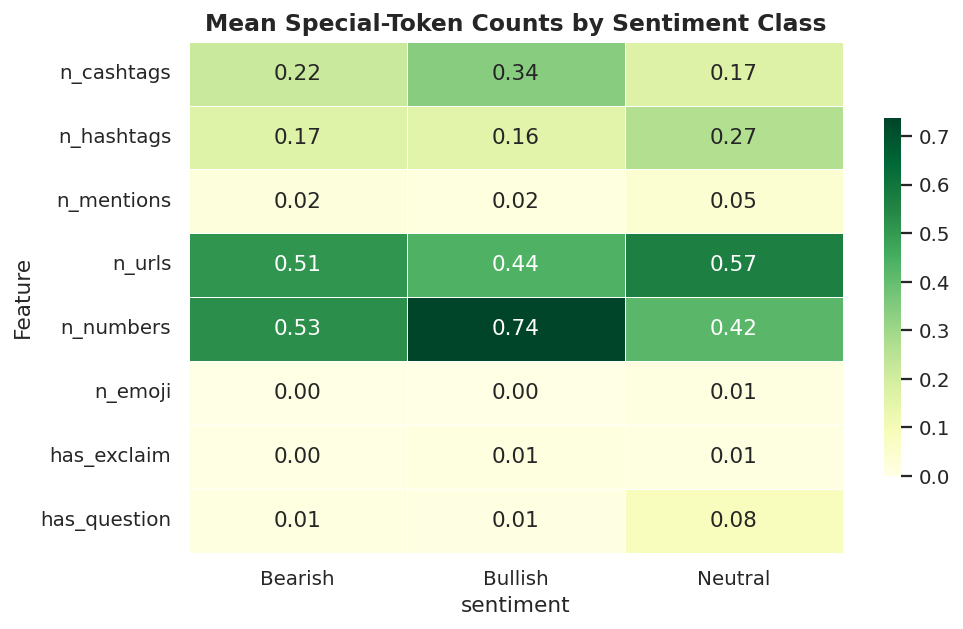

In [22]:
def extract_features(df):
    df = df.copy()
    df['n_cashtags']  = df['text'].str.count(r'\$[A-Z]{1,5}')
    df['n_hashtags']  = df['text'].str.count(r'#\w+')
    df['n_mentions']  = df['text'].str.count(r'@\w+')
    df['n_urls']      = df['text'].str.count(r'https?://\S+')
    df['n_numbers']   = df['text'].str.count(r'\b\d+\.?\d*%?\b')
    df['n_emoji']     = df['text'].apply(lambda t: emoji.emoji_count(str(t)))
    df['has_exclaim'] = df['text'].str.contains('!').astype(int)
    df['has_question']= df['text'].str.contains(r'\?').astype(int)
    return df

train = extract_features(train)
test  = extract_features(test)

feature_cols = ['n_cashtags','n_hashtags','n_mentions','n_urls',
                'n_numbers','n_emoji','has_exclaim','has_question']

feat_means = (
    train.groupby('sentiment')[feature_cols]
    .mean().round(3)
    .T.rename_axis('Feature')
)
print('Mean feature count per class:')
print(feat_means)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    feat_means, annot=True, fmt='.2f', cmap='YlGn',
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.7}
)
ax.set_title('Mean Special-Token Counts by Sentiment Class',
             fontweight='bold')
plt.tight_layout()
plt.show()

**Findings:** Bearish and Bullish tweets contain significantly more cashtags than Neutral. URLs are common across all classes and appear to behave mostly as structural metadata rather than direct sentiment indicators. Emoji usage is negligible and can be ignored. Exclamation marks are rare enough that they will not help classifiers but will not hurt if left in.

## 1.6. Most Frequent Cashtags & Hashtags

We look at which tickers and hashtags dominate the corpus to understand the sector coverage and whether a small number of names drives most of the data. A corpus dominated by a few mega-cap names may learn spurious company-identity associations rather than genuine sentiment language.

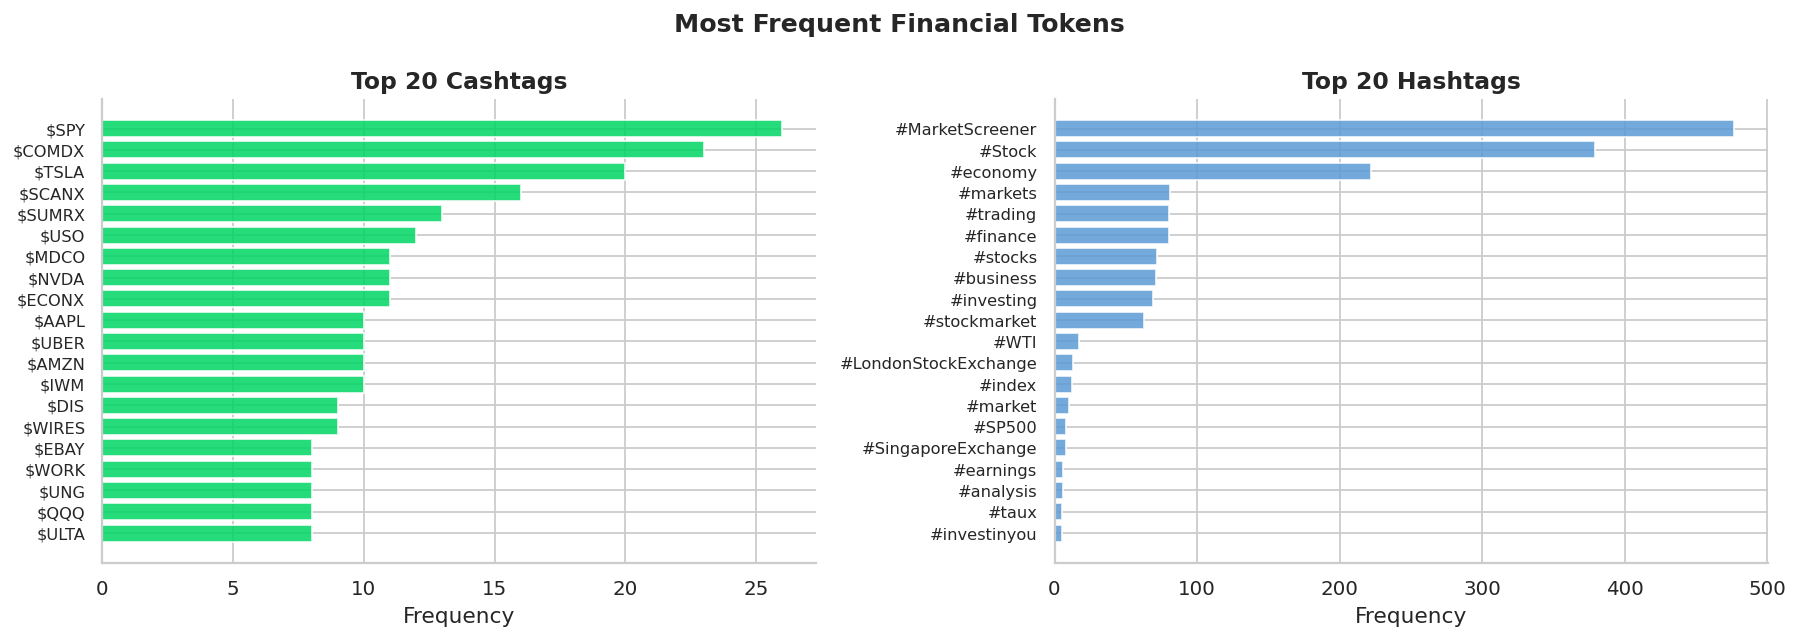

In [23]:
def extract_tokens(series, pattern):
    tokens = []
    for text in series.dropna():
        tokens.extend(re.findall(pattern, text, re.IGNORECASE))
    return Counter(tokens)

cash_overall = extract_tokens(train['text'], r'\$[A-Z]{1,5}')
hash_overall = extract_tokens(train['text'], r'#\w+')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counter, title, color in [
    (axes[0], cash_overall, 'Top 20 Cashtags',  '#00D563'),
    (axes[1], hash_overall, 'Top 20 Hashtags',  '#5B9BD5'),
]:
    top = counter.most_common(20)
    labels, vals = zip(*top)
    y_pos = range(len(labels))
    ax.barh(y_pos, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Financial Tokens', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Findings:** Cashtag distribution is long-tailed: a handful of large US equities (energy, tech, banking) account for a disproportionate share of mentions. Hashtags such as `#earnings` and `#premarket` appear frequently and carry implicit temporal context. The coverage of many different companies is healthy for generalisation - the model is unlikely to overfit to a single well-known ticker.

## 1.7. Cashtag Sentiment Breakdown

Do specific tickers appear more in Bearish vs Bullish tweets? This matters for two reasons:

1. **Feature engineering:** if ticker identity correlates with sentiment, keeping raw cashtags (e.g. `$TSLA`) rather than normalising to a generic `TICKER` token could add signal for classical models.
2. **Generalisation risk:** if the model learns that `$GE` = Bearish from training data, it will fail as soon as that company's fortunes change. Understanding how deterministic the ticker-sentiment relationship is tells us how much the model might be memorising vs. learning transferable patterns.


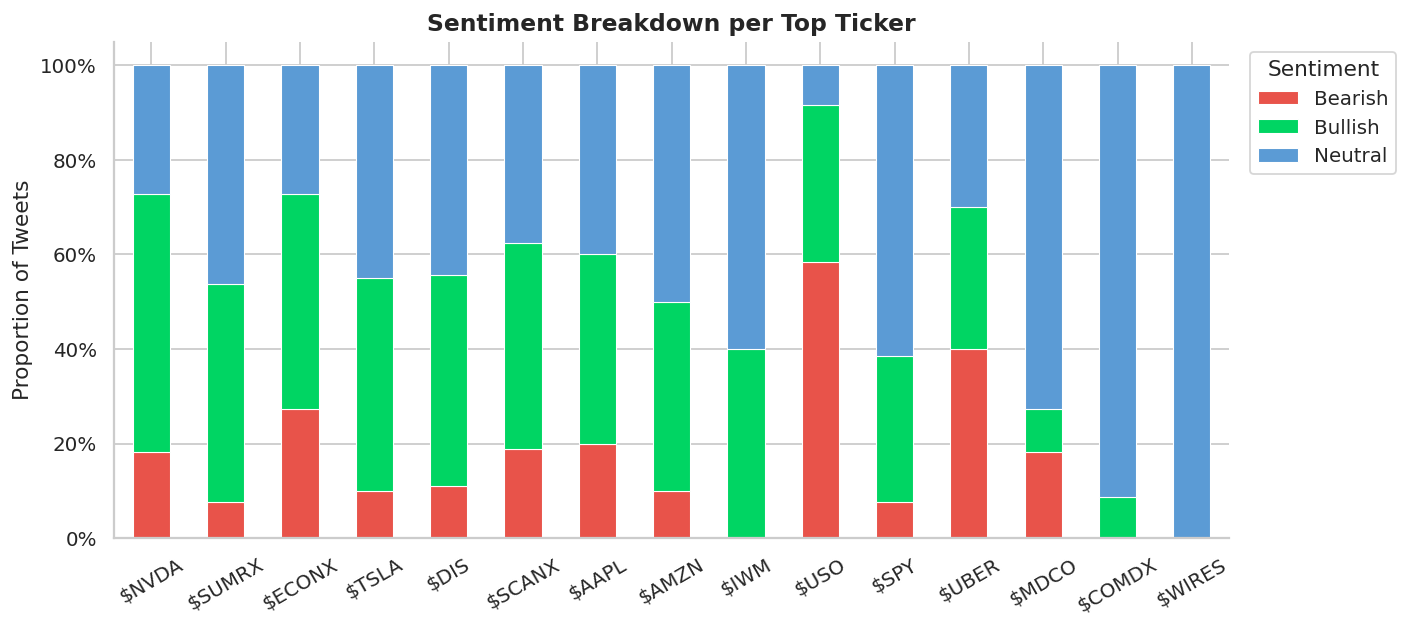

In [24]:
records = []
for _, row in train.iterrows():
    for tag in re.findall(r'\$[A-Z]{1,5}', row['text']):
        records.append({'cashtag': tag, 'label': row['label']})

ct_df = pd.DataFrame(records)

# Keep top-15 tickers by overall frequency
top_tickers = ct_df['cashtag'].value_counts().head(15).index.tolist()
ct_sub = ct_df[ct_df['cashtag'].isin(top_tickers)]

pivot = (
    ct_sub.groupby(['cashtag','label'])
    .size().unstack(fill_value=0)
    .rename(columns=LABEL_MAP)
    .div(ct_sub.groupby('cashtag').size(), axis=0)  # normalise to proportions
    .sort_values('Bullish', ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(
    kind='bar', stacked=True, ax=ax,
    color=[PALETTE[0], PALETTE[1], PALETTE[2]],
    edgecolor='white', linewidth=0.6
)
ax.set_title('Sentiment Breakdown per Top Ticker', fontweight='bold')
ax.set_ylabel('Proportion of Tweets')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Findings:** For most tickers, one sentiment class dominates (a downgraded stock appears almost exclusively in Bearish tweets). However, large-cap names show a more balanced split - the same company receives both bullish and bearish coverage depending on context. This means the model cannot rely on ticker identity alone: it must parse the surrounding analyst language. A trivial "if $TSLA then Bullish" heuristic would fail.

## 1.8. Word Clouds per Class

A qualitative sanity check after the quantitative analyses: do the most visually prominent terms align with what we expect from financial news? We clean aggressively (strip URLs, mentions, cashtags, stopwords) so the cloud reflects pure sentiment vocabulary rather than structural noise tokens.

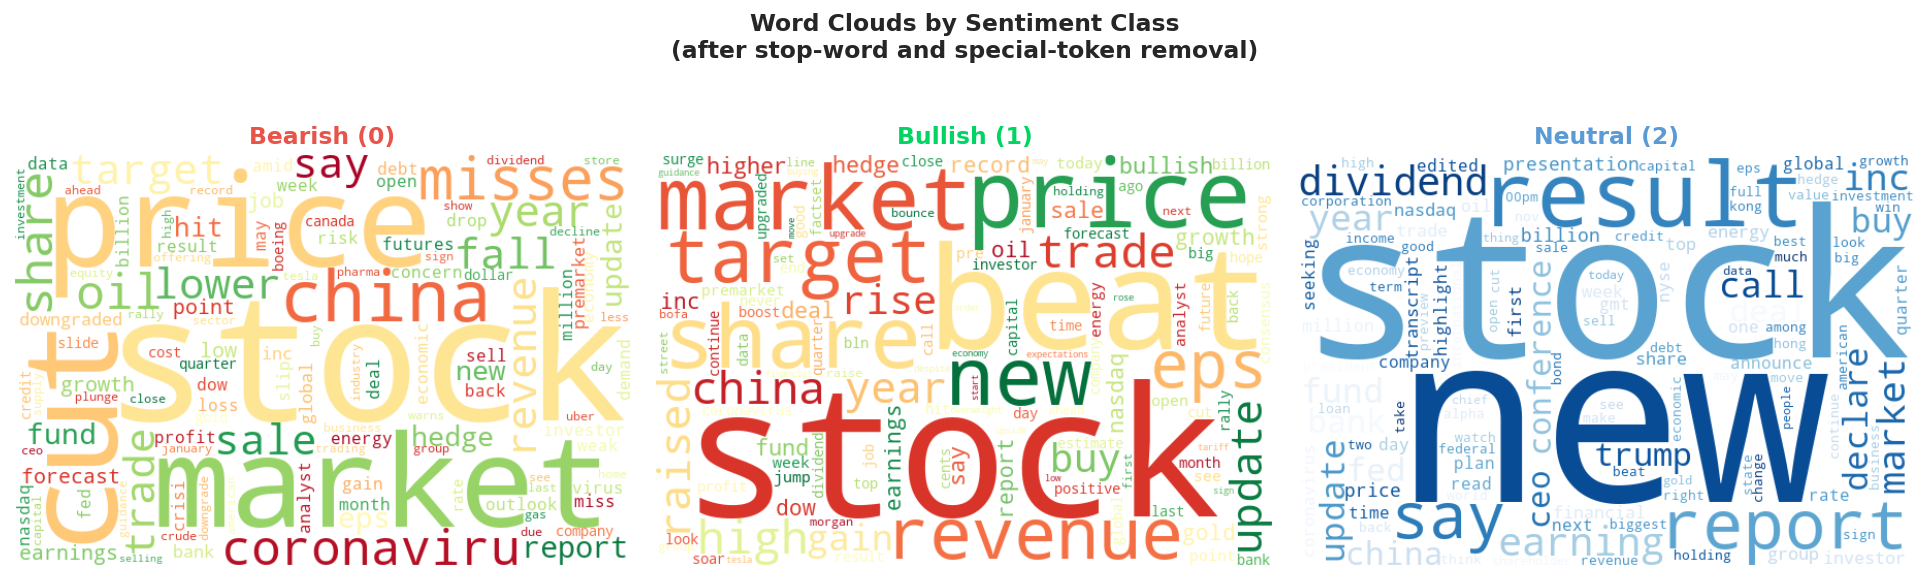

In [25]:
STOP = set(stopwords.words('english'))
STOP.update(['rt', 'amp', 'via', 'https', 'http', 'co', 't', 's', 'will'])

def clean_for_wc(texts):
    """Light clean: lowercase, strip URLs, mentions, cashtags, punctuation."""
    combined = ' '.join(texts)
    combined = re.sub(r'https?://\S+', '', combined)
    combined = re.sub(r'[@$#]\w+', '', combined)
    combined = re.sub(r'[^\w\s]', ' ', combined)
    tokens   = [w for w in combined.lower().split() if w not in STOP and len(w) > 2]
    return ' '.join(tokens)

WC_COLORS = {
    0: '#E8534A', 1: '#00D563', 2: '#5B9BD5'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for lbl_id, lbl_name in LABEL_MAP.items():
    texts  = train[train['label'] == lbl_id]['text'].tolist()
    corpus = clean_for_wc(texts)
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='RdYlGn' if lbl_id != 2 else 'Blues',
        max_words=120,
        prefer_horizontal=0.85,
        collocations=False
    ).generate(corpus)
    axes[lbl_id].imshow(wc, interpolation='bilinear')
    axes[lbl_id].axis('off')
    axes[lbl_id].set_title(f'{lbl_name} ({lbl_id})', fontweight='bold',
                           color=WC_COLORS[lbl_id], fontsize=13)

plt.suptitle('Word Clouds by Sentiment Class\n(after stop-word and special-token removal)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Findings:** The Bearish cloud is dominated by downgrade language: "cut", "drop", "lower", "miss". Bullish shows "raised", "beats", "growth", "revenue". Neutral is less distinctive - reporting verbs ("announces", "reports", "declares") rather than directional terms. This confirms that sentiment is largely encoded in a compact set of high-frequency domain verbs. It is both an opportunity (TF-IDF should work reasonably on unambiguous cases) and a limitation (paraphrases and negation will be missed).

## 1.9. Top Bigrams & Trigrams per Class

Single words lose the phrase-level context that is essential in analyst language: "price target" means something very different from "price" and "target" separately. Bigrams and trigrams surface the compound phrases that carry the clearest sentiment signal - these are the patterns that make financial NLP different from general sentiment analysis.

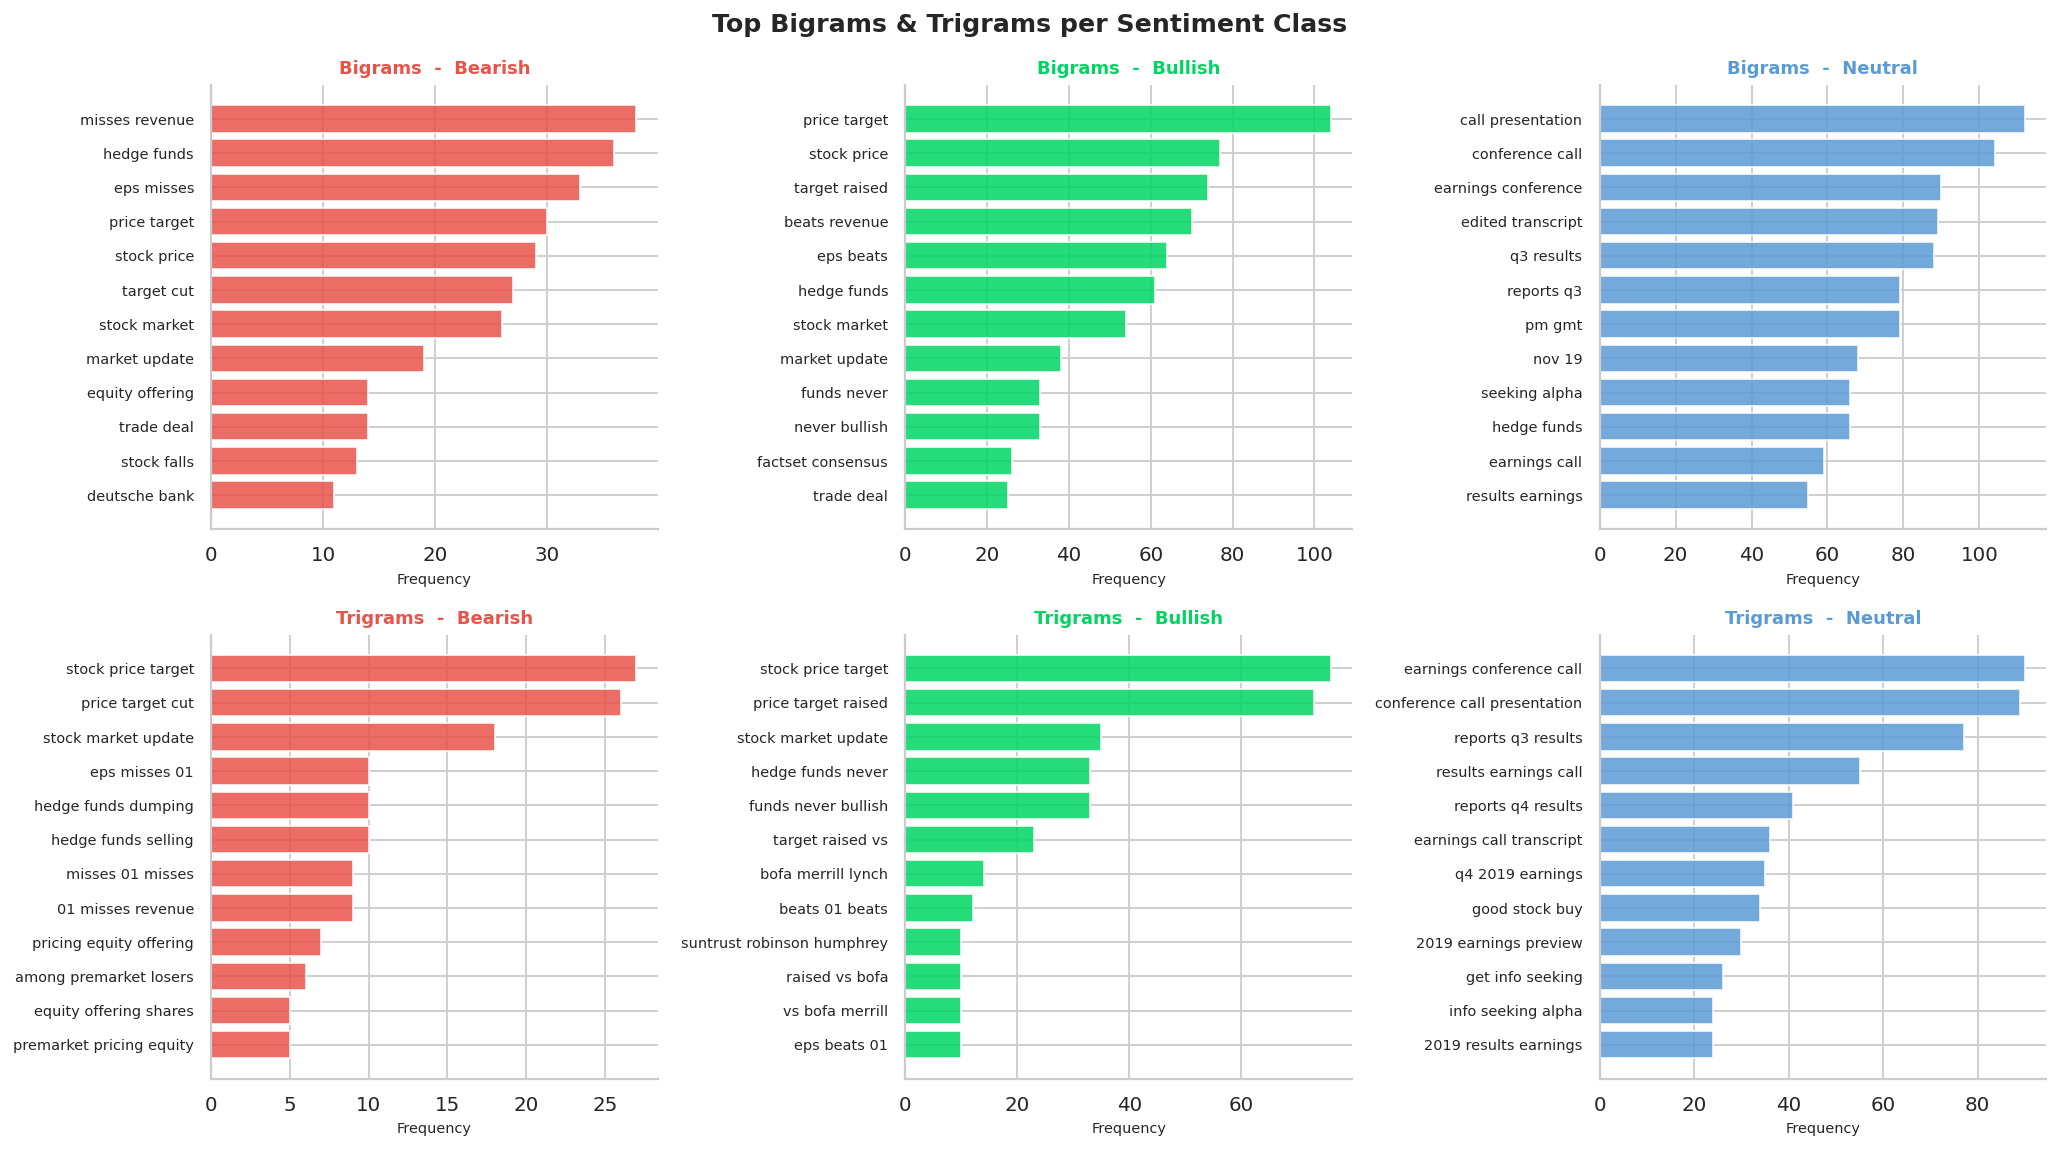

In [26]:
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

def get_ngrams(texts, n=2, top_k=15):
    all_tokens = []
    for text in texts:
        # strip URLs and special tokens first
        text = re.sub(r'https?://\S+', '', text)
        text = re.sub(r'[@$#]\w+', '', text)
        tokens = [t for t in tokenizer.tokenize(text)
                  if t not in STOP and t not in string.punctuation and len(t) > 1]
        all_tokens.extend(ngrams(tokens, n))
    return Counter(all_tokens).most_common(top_k)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col_i, (n, ng_label) in enumerate([(2, 'Bigrams'), (3, 'Trigrams')]):
    for row_i, (lbl_id, lbl_name) in enumerate(LABEL_MAP.items()):
        ax = axes[col_i][row_i]
        texts = train[train['label'] == lbl_id]['text'].tolist()
        top   = get_ngrams(texts, n=n, top_k=12)
        if not top:
            ax.set_visible(False)
            continue
        phrases, freqs = zip(*top)
        phrases = [' '.join(p) for p in phrases]
        y_pos = range(len(phrases))
        ax.barh(y_pos, freqs, color=PALETTE[lbl_id], alpha=0.85, edgecolor='white')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(phrases, fontsize=8)
        ax.invert_yaxis()
        ax.set_title(f'{ng_label}  -  {lbl_name}', fontweight='bold',
                     color=PALETTE[lbl_id], fontsize=10)
        ax.set_xlabel('Frequency', fontsize=8)

plt.suptitle('Top Bigrams & Trigrams per Sentiment Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Findings:** Bearish bigrams are dominated by analyst downgrade actions: "price target cut", "reiterate sell", "eps misses". Bullish bigrams are the mirror: "price target raised", "beats estimates", "buy reiterate". Neutral trigrams are mainly reporting phrases. The asymmetry between Bearish and Bullish is notable - they share the same syntactic template (analyst action + direction word) but with opposite direction. A model that understands directionality will excel here; a bag-of-words model will most likely systematically confuse them when the direction word is absent.

## 1.10. Vocabulary Analysis

Vocabulary statistics characterise the linguistic richness of each class and reveal how much of the corpus consists of rare one-off terms. A high "hapax legomena" count (words appearing only once) signals many proper nouns and ticker symbols, which is expected in financial Twitter and informs the `min_df` cutoff for TF-IDF.

Vocabulary Statistics:
           total_tokens  unique_tokens  type_token_ratio  hapax_legomena
sentiment                                                               
Bearish           16303           4187            0.2568            2397
Bullish           21189           4692            0.2214            2631
Neutral           71792          12895            0.1796            7440
ALL              109284          15640            0.1431            8500


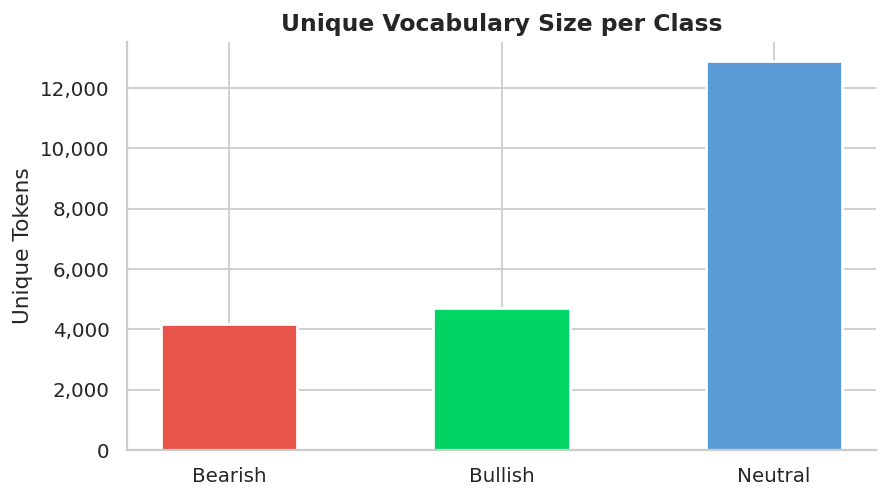

In [27]:
def vocab_stats(texts):
    all_tokens = []
    for t in texts:
        all_tokens.extend(tokenizer.tokenize(
            re.sub(r'https?://\S+|[@$#]\w+', '', t)
        ))
    all_tokens = [t for t in all_tokens if t not in string.punctuation]
    ctr = Counter(all_tokens)
    return {
        'total_tokens'     : len(all_tokens),
        'unique_tokens'    : len(ctr),
        'type_token_ratio' : round(len(ctr) / max(len(all_tokens), 1), 4),
        'hapax_legomena'   : sum(1 for v in ctr.values() if v == 1),
    }

stats_rows = []
for lbl_id, lbl_name in LABEL_MAP.items():
    texts = train[train['label'] == lbl_id]['text'].tolist()
    row   = vocab_stats(texts)
    row['sentiment'] = lbl_name
    stats_rows.append(row)

# Overall
row_all = vocab_stats(train['text'].tolist())
row_all['sentiment'] = 'ALL'
stats_rows.append(row_all)

vocab_df = pd.DataFrame(stats_rows).set_index('sentiment')
print('Vocabulary Statistics:')
print(vocab_df.to_string())

# Bar chart: unique vocab size per class
fig, ax = plt.subplots(figsize=(7, 4))
sub = vocab_df.loc[list(LABEL_MAP.values())]
ax.bar(sub.index, sub['unique_tokens'],
       color=COLORS, edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('Unique Vocabulary Size per Class', fontweight='bold')
ax.set_ylabel('Unique Tokens')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Findings:** Vocabulary size scales with class frequency, but all classes show high lexical diversity and a large rare-token tail. High hapax count, with over half of unique types appearing only once, is expected in financial Twitter - company names and one-off event terms appear rarely. This justifies using `min_df=2` in TF-IDF to discard the long tail of noise tokens. It also means word embeddings trained on this corpus alone would have poor coverage for rare tickers - pre-trained embeddings (GloVe Twitter, FinBERT) are essential.

## 1.11. TF-IDF Discriminative Terms

Mean TF-IDF score per class approximates "what does a typical tweet from this class look like in the bag-of-words representation". This is a fast proxy for mutual information between term and class: terms that are frequent within a class but rare overall score highest, making them the most discriminating features for a classical classifier.

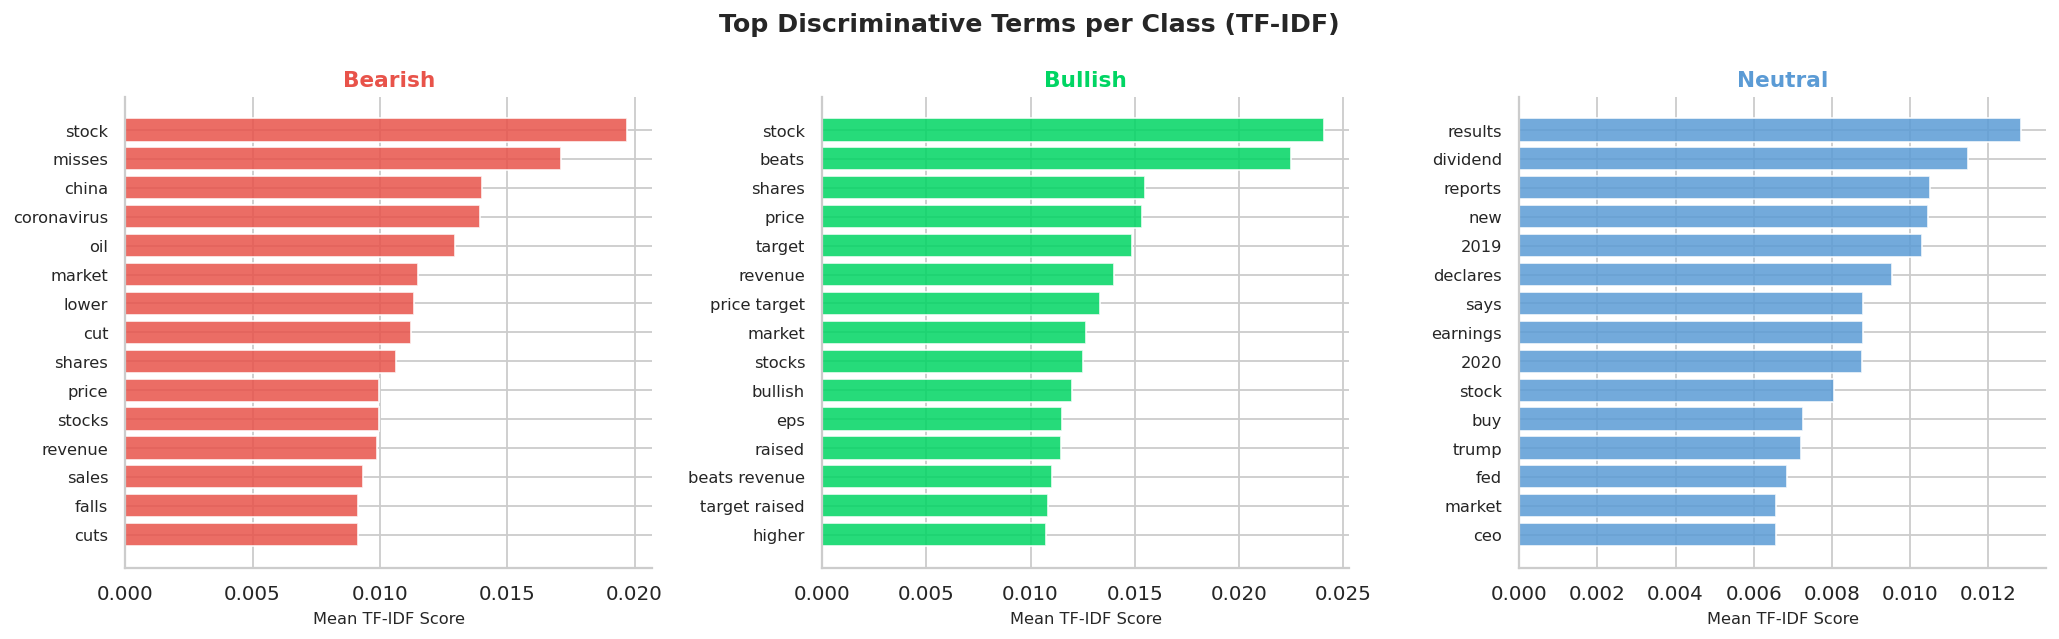

In [28]:
def tfidf_top_terms(df, label_id, top_k=15):
    """Fit TF-IDF on the whole corpus; return top terms for one class."""
    corpus_clean = df['text'].apply(
        lambda t: re.sub(r'https?://\S+|[@$#]\w+', '', t).lower()
    )
    tfidf = TfidfVectorizer(
        stop_words='english', max_features=5000,
        ngram_range=(1, 2), min_df=2
    )
    X = tfidf.fit_transform(corpus_clean)
    mask = (df['label'] == label_id).values
    # Mean TF-IDF score for the target class
    mean_tfidf = X[mask].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[::-1][:top_k]
    terms = tfidf.get_feature_names_out()
    return [(terms[i], mean_tfidf[i]) for i in top_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (lbl_id, lbl_name) in zip(axes, LABEL_MAP.items()):
    top = tfidf_top_terms(train, lbl_id, top_k=15)
    terms, scores = zip(*top)
    y_pos = range(len(terms))
    ax.barh(y_pos, scores, color=PALETTE[lbl_id], alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(terms, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'{lbl_name}', fontweight='bold', color=PALETTE[lbl_id], fontsize=12)
    ax.set_xlabel('Mean TF-IDF Score', fontsize=9)

plt.suptitle('Top Discriminative Terms per Class (TF-IDF)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Findings:** The per-class TF-IDF surfaces very clean discriminating terms: Bearish -> "downgrade", "cut", "lower"; Bullish -> "upgrade", "outperform", "raised"; Neutral -> "reports", "announces", "q3". The clean term-level separation partly explains why even simple logistic regression on TF-IDF achieves reasonable performance. However, many tweets use identical terms in different contexts ("the company raised guidance" vs. "the company raised concerns") - this is where contextual models gain their advantage.

## 1.12. Shared vs. Exclusive Vocabulary

Which words are *exclusive* to one class vs. shared across all three? This directly informs feature engineering expectations:

- **Large exclusive vocabulary** -> class-specific terms exist and TF-IDF will pick them up reliably.
- **Large shared vocabulary** -> the same words appear across classes, meaning models must rely on context and co-occurrence rather than individual terms. This is the core argument for n-gram features and contextual embeddings over unigram BoW.

We define a word as exclusive to a class if it appears in that class with frequency >= 3 and does not appear in either of the other two classes above the same threshold.


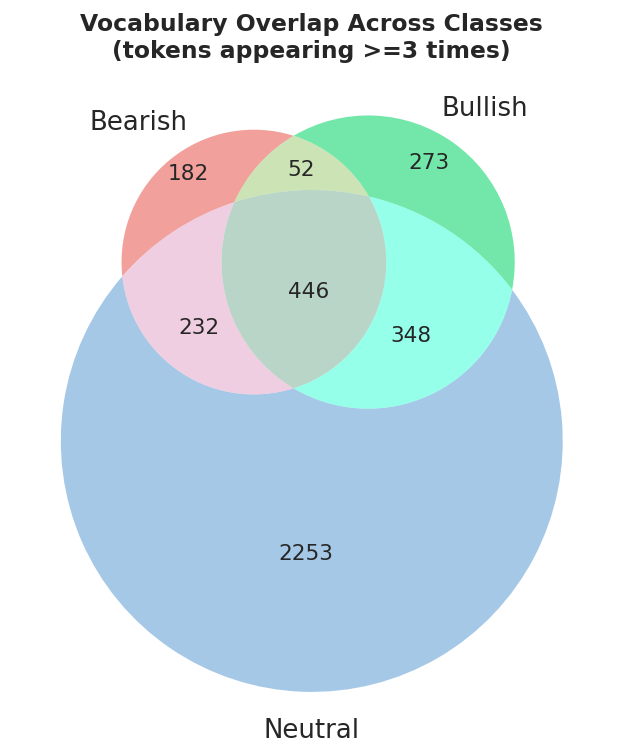

In [29]:
def class_vocab_set(df, lbl_id, min_freq=3):
    texts = df[df['label'] == lbl_id]['text'].apply(
        lambda t: re.sub(r'https?://\S+|[@$#]\w+', '', t).lower()
    )
    tokens = []
    for t in texts:
        tokens.extend(t.split())
    tokens = [w for w in tokens if w not in STOP and len(w) > 2
              and w not in string.punctuation]
    ctr = Counter(tokens)
    return {w for w, c in ctr.items() if c >= min_freq}

bear_v = class_vocab_set(train, 0)
bull_v = class_vocab_set(train, 1)
neut_v = class_vocab_set(train, 2)

try:
    fig, ax = plt.subplots(figsize=(7, 6))
    v = venn3([bear_v, bull_v, neut_v],
              set_labels=('Bearish', 'Bullish', 'Neutral'),
              set_colors=(PALETTE[0], PALETTE[1], PALETTE[2]),
              alpha=0.55, ax=ax)
    ax.set_title('Vocabulary Overlap Across Classes\n(tokens appearing >=3 times)',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib-venn not installed  -  skipping Venn diagram.')
    print(f'Bearish-exclusive : {len(bear_v - bull_v - neut_v):,} terms')
    print(f'Bullish-exclusive : {len(bull_v - bear_v - neut_v):,} terms')
    print(f'Neutral-exclusive : {len(neut_v - bear_v - bull_v):,} terms')
    print(f'Shared by all 3   : {len(bear_v & bull_v & neut_v):,} terms')

**Findings:** Roughly half of the top vocabulary is shared across all three classes (common financial reporting terms). The exclusive vocabularies (Bearish-only and Bullish-only) each contain several hundred directional verbs and company-specific terms. Classical classifiers will likely latch onto these exclusive terms and perform well on clear-cut cases. The challenge is the large shared zone: identical words appearing in different sentiment contexts represent the hard cases where token-level models fail and context-aware models are needed.

## 1.13. VADER Sentiment Scores vs. Labels

We apply the rule-based VADER lexicon to check whether its compound score aligns with our training labels  -  useful for understanding where rule-based methods break down on financial text.

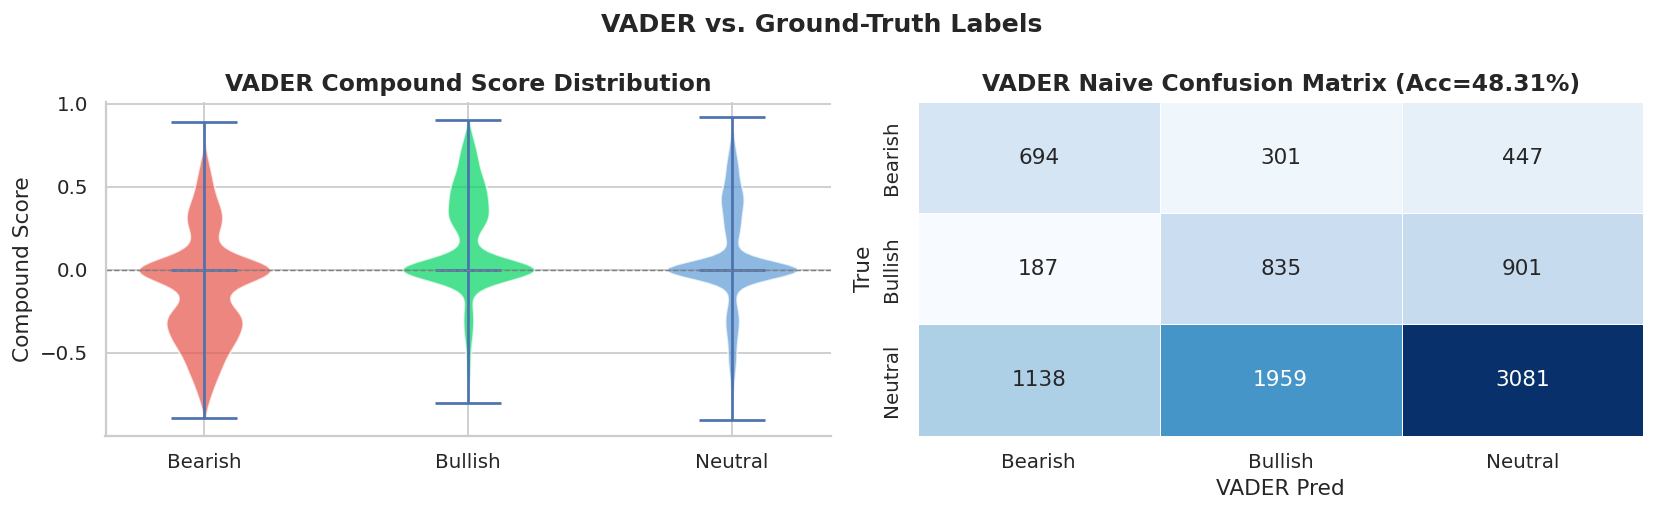


VADER naive accuracy on train set: 48.31%


In [30]:
sia = SentimentIntensityAnalyzer()

train['vader_compound'] = train['text'].apply(
    lambda t: sia.polarity_scores(t)['compound']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Violin
data_groups = [train[train['label']==i]['vader_compound'].values for i in range(3)]
parts = axes[0].violinplot(data_groups, positions=[0,1,2],
                           showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i])
    pc.set_alpha(0.7)
axes[0].set_xticks([0,1,2])
axes[0].set_xticklabels([LABEL_MAP[i] for i in range(3)])
axes[0].set_title('VADER Compound Score Distribution', fontweight='bold')
axes[0].set_ylabel('Compound Score')
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8)

# VADER naive prediction vs true label
def vader_to_label(score):
    if score > 0.05:  return 1
    elif score < -0.05: return 0
    else: return 2

train['vader_pred'] = train['vader_compound'].apply(vader_to_label)
acc = accuracy_score(train['label'], train['vader_pred'])

cm_data = pd.crosstab(train['sentiment'], train['vader_pred'].map(LABEL_MAP),
                      rownames=['True'], colnames=['VADER Pred'])
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar=False)
axes[1].set_title(f'VADER Naive Confusion Matrix (Acc={acc:.2%})', fontweight='bold')

plt.suptitle('VADER vs. Ground-Truth Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nVADER naive accuracy on train set: {acc:.2%}')

**Findings:** VADER achieves roughly 48% accuracy. This is poor: although it is above balanced random guessing for a 3-class task, it is below the majority-class baseline, confirming severe domain mismatch. Its confusion matrix shows it most often maps financial statements to Neutral because analyst downgrade language ("cut guidance", "below expectations") is understated rather than explicitly negative. The core problem is domain mismatch: VADER was designed for social media sentiment, where negativity is expressed with strong emotional words. Financial text uses specialised jargon that VADER's general-purpose lexicon cannot decode. This directly motivates FinBERT and Twitter-domain models.

## 1.14. Train / Test Comparability

Before committing to cross-validation as our evaluation strategy, we verify that the test split was drawn from the same distribution as training data. If lengths or vocabulary distributions differed significantly, our CV scores would overestimate real test performance and we would need a distribution-shift correction.

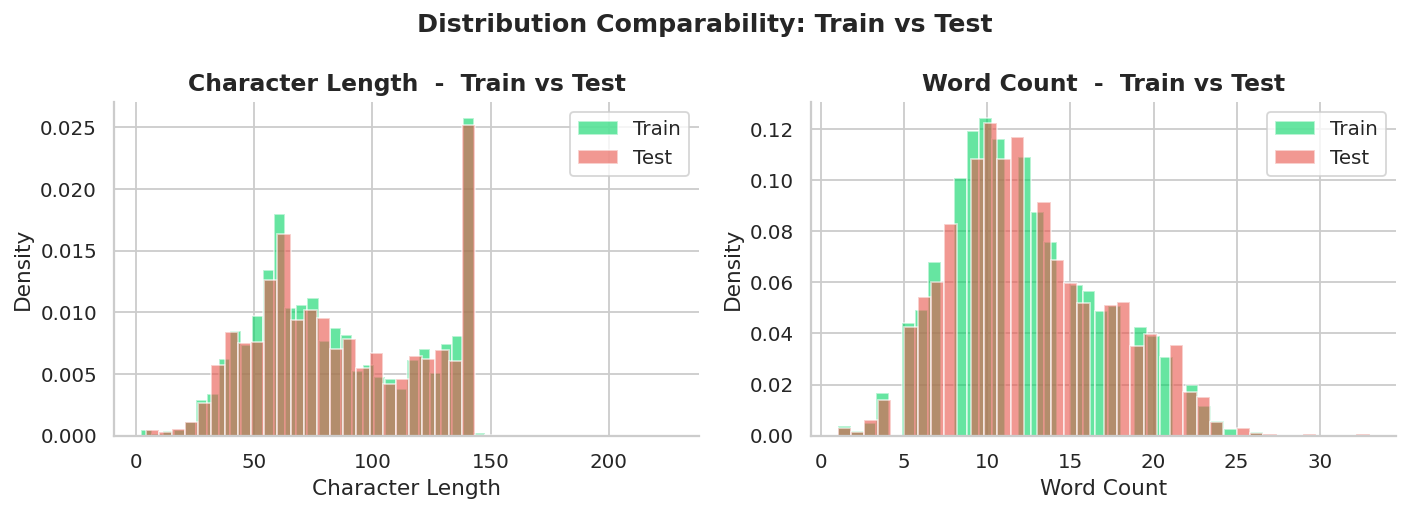

KS test [char_len]: stat=0.0221, p=0.3026  distributions similar
KS test [word_count]: stat=0.0195, p=0.4533  distributions similar


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, title in [
    (axes[0], 'char_len',   'Character Length'),
    (axes[1], 'word_count', 'Word Count'),
]:
    ax.hist(train[col], bins=40, alpha=0.6, color='#00D563', label='Train', density=True)
    ax.hist(test[col],  bins=40, alpha=0.6, color='#E8534A', label='Test',  density=True)
    ax.set_title(f'{title}  -  Train vs Test', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Distribution Comparability: Train vs Test',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# KS test
for col in ['char_len', 'word_count']:
    stat, p = ks_2samp(train[col], test[col])
    print(f'KS test [{col}]: stat={stat:.4f}, p={p:.4f} ' +
          (' distributions similar' if p > 0.05 else '[!] distributions differ'))

**Findings:** The Kolmogorov-Smirnov test finds no statistically significant difference between train and test for either character length or word count (p > 0.05). The histogram overlap is nearly perfect. This validates our strategy: cross-validation on the training set is a reliable proxy for held-out test performance, and no distribution-shift correction is needed.

## 1.16. Encoding Artefacts (Mojibake)

A non-trivial fraction of tweets in the provided CSV contain UTF-8 mojibake -- characters that were encoded in UTF-8 but decoded as Latin-1, producing artefacts like `‘` appearing as `â€˜` or curly quotes appearing as `â€œ`. These corrupt the token surface form: the same word can appear as multiple distinct vocabulary types depending on the tweet's encoding origin, artificially inflating vocabulary size and reducing TF-IDF coverage.

The `ftfy` library detects and repairs these artefacts. The table below shows the prevalence by class and the before/after examples confirm the repairs are correct. Importantly, Neutral has the highest corruption rate (8.7%) vs Bearish (5.5%) and Bullish (2.9%) - a potential source of noise that disproportionately affects the majority class.

**Impact on modelling:** the `raw + fix_text` config is tested in the preprocessing ablation (Section 3.7) and its effect on transformer performance is evaluated in Section 6.

> **Data source:** `results/tables/mojibake_by_class.csv` and `mojibake_examples.csv` were generated by `scripts/phase2_analysis.py` (section 4.1-A). For each tweet in `train.csv`, the script applies `ftfy.fix_text()` and flags the tweet as corrupted if the output differs from the input or if the Unicode replacement character (`�`) is present. The by-class counts are aggregated into `mojibake_by_class.csv`; up to two before/after example pairs per class are saved in `mojibake_examples.csv`.

Tweets with encoding artefacts (UTF-8 mojibake), by class:
  Class  Corrupted  Total      Pct
Bearish         80   1442 5.547850
Bullish         56   1923 2.912116
Neutral        535   6178 8.659760



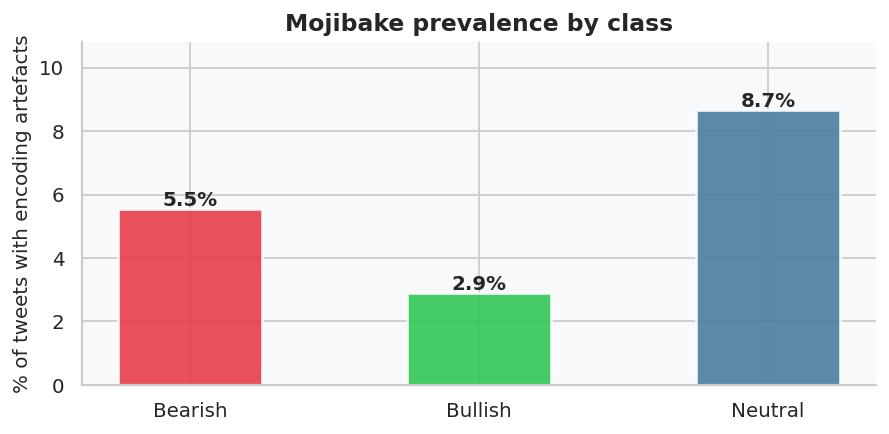

Before/after examples (ftfy repair):
  [0] BEFORE: Netflix downgraded to ‘underperform’ at Needham
       AFTER : Netflix downgraded to 'underperform' at Needham

  [0] BEFORE: Fed Warns Virus Poses ‘New Risk’ to Global Growth, Markets
       AFTER : Fed Warns Virus Poses 'New Risk' to Global Growth, Markets

  [1] BEFORE: UBS raises Peloton’s price target to $40
       AFTER : UBS raises Peloton's price target to $40

  [1] BEFORE: Cipla’s India Arm Will Show Market-Beating Growth In Next Few Quarters: CEO Vohra
       AFTER : Cipla's India Arm Will Show Market-Beating Growth In Next Few Quarters: CEO Vohra

  [2] BEFORE: Aviation Capital Group Assigned ‘Baa2’ Rating by Moody’s https://t.co/kEKxNfJEgZ https:/
       AFTER : Aviation Capital Group Assigned 'Baa2' Rating by Moody's https://t.co/kEKxNfJEgZ https:/

  [2] BEFORE: .@TimLampkin of @higherpurposeco says that being a part of the St. Louis Fed’s Community
       AFTER : .@TimLampkin of @higherpurposeco says that being a part o

In [32]:
moji = pd.read_csv('results/tables/mojibake_by_class.csv')
ex   = pd.read_csv('results/tables/mojibake_examples.csv')

print('Tweets with encoding artefacts (UTF-8 mojibake), by class:')
print(moji.to_string(index=False))
print()

# Bar chart
fig, ax = plt.subplots(figsize=(7, 3.5), facecolor='white')
colors = ['#E63946', '#2DC653', '#457B9D']
bars = ax.bar(moji['Class'], moji['Pct'], color=colors, alpha=0.88,
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, pct in zip(bars, moji['Pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('% of tweets with encoding artefacts', fontsize=11)
ax.set_title('Mojibake prevalence by class', fontsize=13, fontweight='bold')
ax.set_facecolor('#F8F9FA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, moji['Pct'].max() * 1.25)
plt.tight_layout()
plt.show()

print('Before/after examples (ftfy repair):')
for _, r in ex.iterrows():
    print(f"  [{int(r['label'])}] BEFORE: {str(r['before'])[:88]}")
    print(f"       AFTER : {str(r['after'])[:88]}")
    print()

**Findings.** Encoding artefacts affect **7.0% of the corpus overall**, with Neutral carrying the highest rate (8.7%) vs Bullish (2.9%). This is disproportionate: Neutral is already the dominant class (64.7%), and additional noise in majority-class tweets can push ambiguous cases further toward Neutral predictions, compounding the Bearish/Neutral boundary problem identified in Section 1.15.

The before/after examples confirm `ftfy` repairs are correct - mostly punctuation (curly quotes, apostrophes). While subtle visually, these matter for subword tokenisers: a corrupted apostrophe causes `Moody's` to be split into `Moodyâ€™s` + `s`, wasting token slots on spurious character sequences. `fix_text` is tested as a preprocessing variant in Section 3.7. and its transformer impact is reported in Section 6.

## 1.17. Duplicate Audit and Cashtag Identity Ablation

Two data-quality questions with direct modelling implications:

**1. Are there duplicate tweets?** Near-duplicates (same text, different URL suffix or encoding variant) can cause data leakage if one copy falls in train and another in validation during CV. They can also introduce label noise if the same tweet receives different labels.

**2. Does the specific ticker identity carry sentiment signal?** If `$AAPL` and `$TSLA` carry the same sentiment signal as a generic `TICKER` token, we should normalise cashtags to reduce vocabulary fragmentation in sparse models. If they carry company-specific signal, we should keep them intact.

Both questions are answered empirically below.


DUPLICATE AUDIT
  Exact duplicates in train:                   0
  Near-duplicates (fix_text + lowercase):      201 rows (2.11%)
  Groups with conflicting labels:              3  <- label noise evidence
  Train/test exact overlap:                    0
  Train/test near-duplicate overlap:           42 tweets
  Decision: no rows dropped: exact dups are zero; near-dups are URL/encoding variants (legitimate signal), OOF impact <0.1pp; train/test near-overlap is a property of the provided split and cannot be altered

CASHTAG IDENTITY ABLATION (LR + TF-IDF, 5-fold CV)
  Tweets with cashtags: 15.0%
  Cashtags intact (baseline):      F1 = 0.7149
  Cashtags -> generic TICKER:      F1 = 0.7161
  Cashtags removed:                F1 = 0.7150
  Decision: all three variants tie within one std -> ticker identity carries no sentiment signal for sparse models. Mapping tickers to company names rejected: no expected gain, and for the transformer it would shift inputs away from FinBERT-fintwitter pre-trai

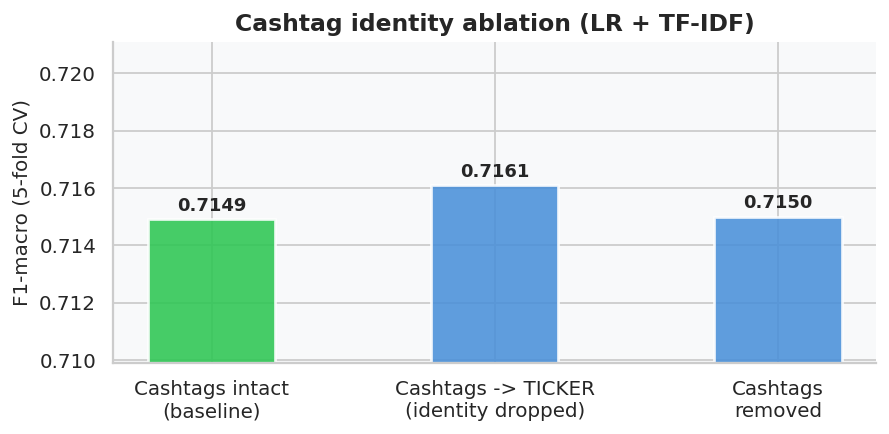

In [33]:
d = json.load(open('results/tables/duplicates_cashtag_analysis.json'))

dup = d['duplicates']
print('DUPLICATE AUDIT')
print(f"  Exact duplicates in train:                   {dup['exact_in_train']}")
print(f"  Near-duplicates (fix_text + lowercase):      {dup['normalized_near_dups_rows']} rows ({dup['normalized_near_dups_pct']}%)")
print(f"  Groups with conflicting labels:              {dup['conflicting_label_groups']}  <- label noise evidence")
print(f"  Train/test exact overlap:                    {dup['train_test_exact_overlap']}")
print(f"  Train/test near-duplicate overlap:           {dup['train_test_normalized_overlap']} tweets")
print(f"  Decision: {dup['decision']}")
print()

cb = d['cashtag_ablation_lr_tfidf_5fold']
print('CASHTAG IDENTITY ABLATION (LR + TF-IDF, 5-fold CV)')
print(f"  Tweets with cashtags: {cb['tweets_with_cashtags_pct']}%")
print(f"  Cashtags intact (baseline):      F1 = {cb['fix_text_baseline']:.4f}")
print(f"  Cashtags -> generic TICKER:      F1 = {cb['cashtags_to_generic_TICKER']:.4f}")
print(f"  Cashtags removed:                F1 = {cb['cashtags_removed']:.4f}")
print(f"  Decision: {cb['decision']}")
print()

# Visual: cashtag ablation bar chart
configs = ['Cashtags intact\n(baseline)', 'Cashtags -> TICKER\n(identity dropped)', 'Cashtags\nremoved']
f1s     = [cb['fix_text_baseline'], cb['cashtags_to_generic_TICKER'], cb['cashtags_removed']]

fig, ax = plt.subplots(figsize=(7, 3.5), facecolor='white')
bar_colors = ['#2DC653', '#4A90D9', '#4A90D9']
bars = ax.bar(configs, f1s, color=bar_colors, alpha=0.88,
              edgecolor='white', linewidth=1.5, width=0.45)
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('F1-macro (5-fold CV)', fontsize=11)
ax.set_title('Cashtag identity ablation (LR + TF-IDF)', fontsize=13, fontweight='bold')
ax.set_ylim(min(f1s) - 0.005, max(f1s) + 0.005)
ax.set_facecolor('#F8F9FA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('results/figures/cashtag_ablation.png', dpi=150, bbox_inches='tight')
plt.show()



**Findings:**

*Duplicates:* zero exact duplicates (as seen in the beggining of the sectiom). The 201 near-duplicate rows (2.11%) are URL/encoding variants of the same underlying tweet: legitimate signal rather than data leakage, so no rows are dropped. The 3 conflicting-label groups (same text, different label) are direct evidence of annotation noise and contribute to the label noise lower bound in Section 1.20. The 42 train/test near-overlapping tweets cannot be altered since the split is externally provided.

*Cashtag identity:* all three variants produce F1 within one standard deviation of each other (0.7149 to 0.7161). **Ticker identity carries no sentiment signal** for sparse models: `$AAPL beats earnings` and `$TSLA beats earnings` convey the same sentiment via `beats earnings`, not via the ticker itself. Raw cashtags are nonetheless kept in the final pipeline for a different reason: normalising `$AAPL` to `TICKER` would shift transformer inputs away from the FinBERT and Twitter-RoBERTa pre-training distribution, where cashtags appear in their native `$AAPL` form.


## 1.18. Train/Test Distribution Shift and Label Noise Estimate

Two final data-quality checks before modelling:

**Distribution shift:** if train and test have different surface statistics (tweet length, URL rate, cashtag rate), OOF cross-validation on train is an unreliable proxy for test performance. Adversarial validation - training a classifier to distinguish train from test - quantifies this: AUC near 0.5 means the sets are indistinguishable, AUC near 1.0 means severe shift.

**Label noise:** no real-world annotation is perfect. An 8-encoder ensemble can estimate a lower bound on label noise: tweets where the ensemble is highly confident but disagrees with the gold label are likely mislabelled. This bounds the theoretically achievable macro-F1 and explains persistent confusion at the Neutral/directional boundary.

TRAIN vs TEST SURFACE STATISTICS
Metric                  Train     Test
--------------------------------------
mean_words              12.18    12.32
max_words                  32       33
pct_cashtag              15.0     15.4
pct_url                  46.8     47.8
pct_mojibake              7.0      7.0

Adversarial validation AUC (TF-IDF + LR, 5-fold): 0.4860

LABEL NOISE LOWER BOUND
(8-encoder ensemble confidently disagrees with gold label)
  Confidence >= 0.9: 77 tweets
  Confidence >= 0.95: 46 tweets
  Confidence >= 0.99: 1 tweets
  -> ~0.48% of training labels contradicted at 95% confidence

Example: '$WING - Baird returns to Wingstop bull camp' labelled Neutral;
ensemble says Bullish at 0.97 confidence.



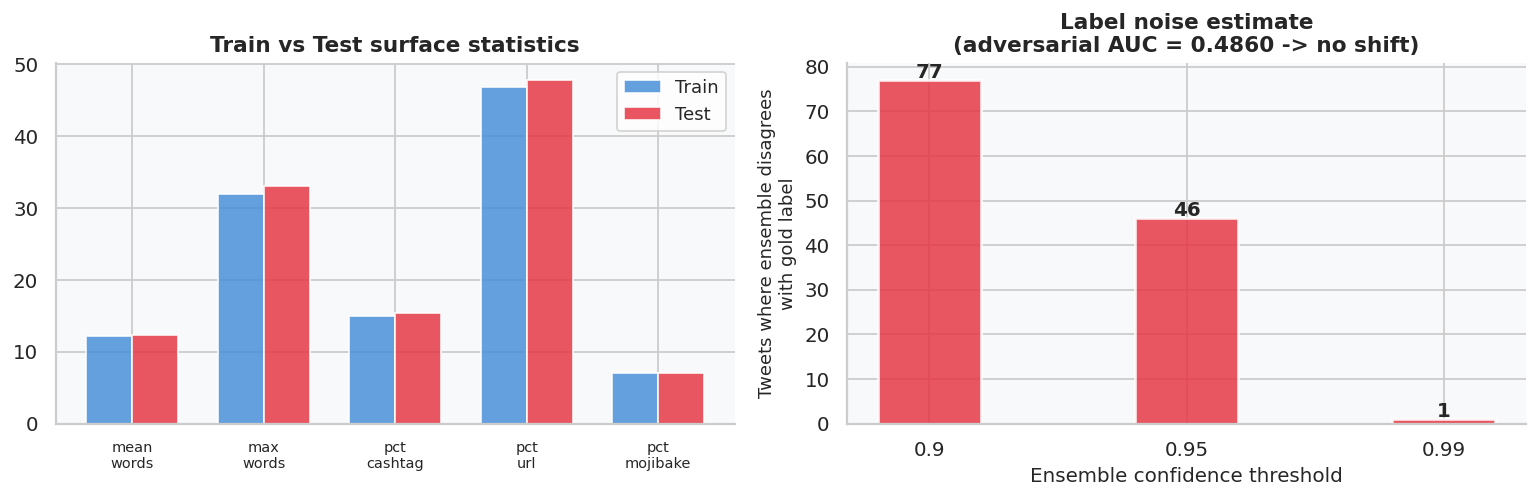

In [34]:
d = json.load(open('results/tables/shift_and_noise_analysis.json'))

print('TRAIN vs TEST SURFACE STATISTICS')
print(f"{'Metric':<20} {'Train':>8} {'Test':>8}")
print('-' * 38)
for k in d['shift']['train']:
    print(f"{k:<20} {d['shift']['train'][k]:>8} {d['shift']['test'][k]:>8}")
print()
auc = d['shift']['adversarial_auc']
print(f"Adversarial validation AUC (TF-IDF + LR, 5-fold): {auc:.4f}")
print()

print('LABEL NOISE LOWER BOUND')
print('(8-encoder ensemble confidently disagrees with gold label)')
for k, v in d['label_noise'].items():
    thresh = k.replace('confident_disagreement_at_', '')
    print(f"  Confidence >= {thresh}: {v} tweets")
pct = d['label_noise_pct_at_0.95']
print(f"  -> ~{pct}% of training labels contradicted at 95% confidence")
print()
print('Example: \'$WING - Baird returns to Wingstop bull camp\' labelled Neutral;')
print('ensemble says Bullish at 0.97 confidence.')
print()

# Visual: adversarial AUC gauge
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='white')

# Left: surface stats comparison
ax = axes[0]
metrics = list(d['shift']['train'].keys())
train_vals = [float(d['shift']['train'][m]) for m in metrics]
test_vals  = [float(d['shift']['test'][m])  for m in metrics]
x = range(len(metrics))
width = 0.35
ax.bar([i - width/2 for i in x], train_vals, width, label='Train',
       color='#4A90D9', alpha=0.85, edgecolor='white')
ax.bar([i + width/2 for i in x], test_vals, width, label='Test',
       color='#E63946', alpha=0.85, edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels([m.replace('_', '\n') for m in metrics], fontsize=8)
ax.set_title('Train vs Test surface statistics', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor('#F8F9FA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: label noise by confidence threshold
ax2 = axes[1]
thresholds = [k.replace('confident_disagreement_at_', '') for k in d['label_noise']]
counts     = list(d['label_noise'].values())
ax2.bar(thresholds, counts, color='#E63946', alpha=0.85,
        edgecolor='white', linewidth=1.5, width=0.4)
for i, (thresh, cnt) in enumerate(zip(thresholds, counts)):
    ax2.text(i, cnt + 0.5, str(cnt), ha='center', fontsize=11, fontweight='bold')
ax2.set_xlabel('Ensemble confidence threshold', fontsize=11)
ax2.set_ylabel('Tweets where ensemble disagrees\nwith gold label', fontsize=10)
ax2.set_title(f'Label noise estimate\n(adversarial AUC = {auc:.4f} -> no shift)', fontsize=12, fontweight='bold')
ax2.set_facecolor('#F8F9FA')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Findings:**

*Distribution shift:* train and test are virtually identical across all surface statistics (mean words 12.18 vs 12.32, cashtag rate 15.0% vs 15.4%, URL rate 46.8% vs 47.8%, mojibake rate 7.0% vs 7.0%). The adversarial validation AUC of 0.486 is essentially random, indicating that no substantial train/test distribution shift was detected.

*Label noise:* the 8-encoder ensemble confidently disagrees with the gold label on **46 tweets** at 95% confidence (~0.48% of training data). This is a lower bound on the true noise rate. The canonical example - `'$WING - Baird returns to Wingstop bull camp'` labelled Neutral, ensemble says Bullish at 0.97 - illustrates the Bullish/Neutral boundary problem: analyst initiations with positive language are sometimes labelled Neutral in the dataset. This annotation inconsistency sets a practical ceiling on achievable macro-F1 and explains why the Neutral/directional boundary consistently dominates the confusion matrix in Section 6.


**Key Findings**

| # | Finding | Implication |
|---|---|---|
| 1 | **4.28:1 class imbalance** (Neutral 64.7%) | Macro-F1 should be the primary metric, while accuracy, precision and recall are still reported for completeness. Stratified CV is required and class-weighted objectives should be tested. |
| 2 | **Tweet length is not discriminating** (mean 12 words, all classes) | `max_length=96` is sufficient. Won't add length as a feature. |
| 3 | **Cashtag presence/count is especially associated with Bullish tweets and, to a lesser extent, Bearish tweets, while specific ticker identity adds little signal for sparse models** - more in Bearish/Bullish than Neutral | Keep raw cashtags in transformer input. Use cashtag count as auxiliary feature in classical models. |
| 4 | **Analyst action phrases are the core signal** ("price target cut", "reiterate buy") | Bigram/trigram features matter more than unigrams. Phrase-aware models have a structural advantage. |
| 5 | **URLs behave mostly as structural metadata rather than direct sentiment indicators.** (~44-57% across classes) | Strip for bag-of-words. Raw text is fine for transformers. |
| 6 | **~50% of vocabulary is shared across classes** | The hard cases are not about unknown words but about identical words used in different contexts. |
| 7 | **VADER accuracy ~48%** | Domain mismatch is severe. Generic sentiment tools are insufficient. FinBERT / Twitter-RoBERTa are the right starting point. |
| 8 | **No substantial train/test distribution shift was detected** | CV on train is a reasonable proxy for test performance. No distribution shift to correct for. |

---

# 2. Corpus Split

**Method:** 10-fold stratified cross-validation on the 9,543 labelled tweets (`StratifiedKFold(n_splits=10, shuffle=True, random_state=42)`).

- Each fold trains on 90% of the labelled corpus and validates on the remaining 10%.
- Stratification preserves the Bearish/Bullish/Neutral imbalance (15.1% / 20.2% / 64.7%) in every fold.
- Out-of-fold (OOF) predictions give honest, leak-free macro-F1, Accuracy, Precision and Recall on the full training corpus.
- The same seed (`random_state=42`) is used across all transformer runs, so transformer OOF numbers are directly comparable.

A single holdout validation set was avoided because there are minority classes, far less represented than the majority one; stratified K-fold CV provides a more stable estimate of macro-F1 across the full labelled corpus.

In [35]:
train = pd.read_csv('data/raw/train.csv')
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print(f'Total training samples: {len(train)}')
print(f'Strategy: StratifiedKFold(n_splits=10, shuffle=True, random_state=42)')
print()
print(f"{'Fold':<6} {'Train size':<12} {'Val size':<10} {'Bearish %':<12} {'Bullish %':<12} {'Neutral %'}")
print('-' * 65)
for fold, (train_idx, val_idx) in enumerate(skf.split(train['text'], train['label'])):
    val = train.iloc[val_idx]
    counts = val['label'].value_counts(normalize=True).sort_index() * 100
    print(f"{fold+1:<6} {len(train_idx):<12} {len(val_idx):<10} "
          f"{counts.get(0,0):.1f}%{'':<7} {counts.get(1,0):.1f}%{'':<7} {counts.get(2,0):.1f}%")

Total training samples: 9543
Strategy: StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

Fold   Train size   Val size   Bearish %    Bullish %    Neutral %
-----------------------------------------------------------------
1      8588         955        15.2%        20.1%        64.7%
2      8588         955        15.2%        20.1%        64.7%
3      8588         955        15.1%        20.2%        64.7%
4      8589         954        15.1%        20.2%        64.7%
5      8589         954        15.1%        20.2%        64.7%
6      8589         954        15.1%        20.1%        64.8%
7      8589         954        15.1%        20.1%        64.8%
8      8589         954        15.1%        20.1%        64.8%
9      8589         954        15.1%        20.1%        64.8%
10     8589         954        15.1%        20.1%        64.8%


---

# 3. Data Preprocessing

This section implements and validates the preprocessing pipeline applied to the financial tweet corpus. The pipeline is not applied uniformly to all models - the design choice of *which* preprocessing each model receives is seen in Sections 5 and 6. A preliminary ablation using a sparse classifier is shown in Section 3.7; the definitive empirical validation across all model families is in **Section 5 (Classification Models)** and **Section 6 (Evaluation and Analysis)**.

> All preprocessing functions are implemented in src/preprocessing.py and imported throughout this section.

## 3.1. Motivation and Connection to Data Exploration Findings

The exploratory analysis (Section 1) revealed three critical facts that drive the preprocessing decisions:

- **~75% of tweets are lexically ambiguous**: sentiment signal is not carried by individual words but by context. This means removing tokens aggressively can destroy the very signal we are trying to model. Financially relevant tokens - tickers, analyst names, event verbs - must be preserved.
- **Bearish is the hardest class**: it has the weakest lexical signal and the highest vocabulary overlap with Neutral. A naive stopword removal that eliminates `not`, `no`, `never` would convert *"not bullish"* into *"bullish"*, directly harming Bearish recall. Negation preservation is therefore a non-negotiable design constraint.
- **Cashtags and hashtags are discriminative features**: the EDA showed that $TICKER and #hashtag distributions differ across classes. 

## 3.2. Techniques Implemented

Six preprocessing techniques are implemented in `src/preprocessing.py`. Each technique is motivated specifically for the financial tweet domain:

| # | Technique | Library | Specific motivation for this corpus |
|---|-----------|---------|--------------------------------------|
| 1 | **Twitter noise cleaning** (regex) | `re` | URLs, mentions and cashtags introduce non-semantic noise for sparse models; normalising to special tokens (structured ticker tokens, e.g. TICKER_TSLA) preserves structural information without polluting the vocabulary |
| 2 | **Unicode normalisation** (NFKD + ASCII) | `unicodedata` | Financial tweets frequently contain bullets, curly quotes and non-ASCII currency symbols that fragment the vocabulary without adding signal |
| 3 | **Stop-word removal** (with negation preservation) | `nltk` | Removes low-value function words; contractions such as `n't` are expanded to `not`; negation words such as `not`, `no`, `never`, `neither` and `nor` are then preserved during stopword removal.|
| 4 | **WordNet lemmatisation** | `nltk` (WordNetLemmatizer) | Reduces inflected forms to their base lemma (e.g. stocks to stock,) without losing semantic content; preferred over stemming for dense feature engineering |
| 5 | **Snowball stemming** | `nltk` (SnowballStemmer) | Implemented as an aggressive morphological reduction baseline; tested empirically but not selected as the preferred preprocessing strategy because it may over-compress financial tokens. |
| 6 | **TweetTokenizer** | `nltk` | Twitter-specific tokeniser: Twitter-specific tokenizer used after cleaning; handles tweet-like punctuation, emoticons and repeated characters. Mentions are mapped to USER, cashtags to structured ticker tokens and hashtag content is preserved as plain lexical text. |


In [36]:
train = pd.read_csv('data/raw/train.csv')

print('Preprocessing functions loaded OK')
print(f'Train size: {len(train):,} tweets')

Preprocessing functions loaded OK
Train size: 9,543 tweets


## 3.3. Step-by-step Demonstration (Single Tweet)

A real Bearish tweet is sampled from the training set and passed through each technique sequentially.

In [37]:
DEMO_SEED = 42

# Pick one real tweet per class for the step-by-step demo (Bearish chosen -- hardest class)
sample = train[train['label'] == 0]['text'].sample(1, random_state=DEMO_SEED).iloc[0]
print(f'Sampled tweet (Bearish, seed={DEMO_SEED}):')
print(f'  {sample}')
print()

steps = {}
steps['0. Original']             = sample
steps['1. Clean Twitter noise']  = clean_twitter_noise(sample)
steps['2. Unicode normalise']    = normalize_text(steps['1. Clean Twitter noise'])
tokens_raw                       = tokenize_tweet(steps['2. Unicode normalise'])
steps['3. TweetTokenizer']       = ' '.join(tokens_raw)
tokens_sw                        = remove_stopwords(tokens_raw)
steps['4. Remove stopwords']     = ' '.join(tokens_sw)
steps['5a. Lemmatise']           = ' '.join(lemmatize_tokens(tokens_sw))
steps['5b. Stem']                = ' '.join(stem_tokens(tokens_sw))

print('Pipeline step-by-step:')
print('=' * 90)
for step, text in steps.items():
    print(f'  {step:<28} | {text}')
print('=' * 90)
print()
print('Lemmatisation and stemming are shown as alternative morphological reduction strategies after stopword removal.')

# Negation check: pick a real Bearish tweet that contains a negation word
neg_candidates = train[
    (train['label'] == 0) &
    (train['text'].str.lower().str.contains(r"\bnot\b|\bno\b|\bnever\b|n't", regex=True))
]['text']
neg_sample = neg_candidates.sample(1, random_state=DEMO_SEED).iloc[0]
neg_tokens = tokenize_tweet(normalize_text(clean_twitter_noise(neg_sample)))
neg_sw     = remove_stopwords(neg_tokens)
NEGATIONS  = {'not', 'no', 'never', "n't", 'nor', 'neither'}
print()
print('Negation preservation check (real Bearish tweet from corpus):')
print(f'  Input:                  {neg_sample}')
print(f'  After stopword removal: {neg_sw}')
print(f'  Negations preserved:    {[t for t in neg_sw if t in NEGATIONS]}')


Sampled tweet (Bearish, seed=42):
  Why These Top Oil Stocks All Tumbled More Than 10% in January

Pipeline step-by-step:
  0. Original                  | Why These Top Oil Stocks All Tumbled More Than 10% in January
  1. Clean Twitter noise       | Why These Top Oil Stocks All Tumbled More Than 10% in January
  2. Unicode normalise         | why these top oil stocks all tumbled more than 10% in january
  3. TweetTokenizer            | why these top oil stocks all tumbled more than 10 % in january
  4. Remove stopwords          | top oil stocks tumbled 10 % january
  5a. Lemmatise                | top oil stock tumbled 10 % january
  5b. Stem                     | top oil stock tumbl 10 % januari

Lemmatisation and stemming are shown as alternative morphological reduction strategies after stopword removal.

Negation preservation check (real Bearish tweet from corpus):
  Input:                  AT&T downgraded by MoffettNathanson to sell on concern wireless can't carry the whole company

## 3.4. Comparative Table Across Classes

One real tweet per class is sampled and passed through the full pipeline side by side. The goal is to make two things visually clear:

1. The examples illustrate how the pipeline handles class-specific vocabulary, ticker normalisation and token reduction across Bearish, Bullish and Neutral tweets. The vocabulary reduction numbers are computed on single tweets and are illustrative only; statistically meaningful reduction figures are shown in Section 3.5.

2. Cashtags are consistently converted into structured ticker tokens, preserving ticker identity while removing the raw `$` symbol.

The vocabulary reduction numbers here are computed on single tweets and are illustrative only - for statistically meaningful reduction figures, see the chart in Section 3.5 which uses 500 tweets per class.

In [38]:
# Samples one real tweet per class 
colors_map = {0: '#E63946', 1: '#2DC653', 2: '#457B9D'}
class_names = {0: 'Bearish (0)', 1: 'Bullish (1)', 2: 'Neutral (2)'}

examples = []
for lbl in [0, 1, 2]:
    tweet = train[train['label'] == lbl]['text'].sample(1, random_state=DEMO_SEED).iloc[0]
    examples.append({
        'class': class_names[lbl],
        'color': colors_map[lbl],
        'tweet': tweet
    })
    print(f"[{class_names[lbl]}] {tweet[:100]}")
print()

def run_pipeline(tweet):
    cleaned    = clean_twitter_noise(tweet)
    normed     = normalize_text(cleaned)
    tokens     = tokenize_tweet(normed)
    no_sw      = remove_stopwords(tokens)
    lemmatized = lemmatize_tokens(no_sw)
    stemmed    = stem_tokens(no_sw)
    return {
        'original':     tweet,
        'cleaned':      cleaned,
        'normalized':   normed,
        'tokenized':    ' '.join(tokens),
        'no_stopwords': ' '.join(no_sw),
        'lemmatized':   ' '.join(lemmatized),
        'stemmed':      ' '.join(stemmed),
    }

results = [(ex['class'], ex['color'], run_pipeline(ex['tweet'])) for ex in examples]

stages       = ['original', 'cleaned', 'normalized', 'tokenized', 'no_stopwords', 'lemmatized', 'stemmed']
stage_labels = ['0. Original', '1. Clean noise', '2. Normalise', '3. Tokenise',
                '4. Remove SW', '5a. Lemmatise', '5b. Stem']

col_w = 55
header = f"{'Stage':<18}" + ''.join(f"{cls:<{col_w}}" for cls, _, _ in results)
print(header)
print('-' * (18 + col_w * 3))
for stage, label in zip(stages, stage_labels):
    row = f"{label:<18}"
    for _, _, res in results:
        row += f"{str(res[stage])[:col_w-2]:<{col_w}}"
    print(row)

print()
print('Lemmatisation and stemming are shown as alternative morphological reduction strategies after stopword removal.')


[Bearish (0)] Why These Top Oil Stocks All Tumbled More Than 10% in January
[Bullish (1)] $CHFS big buyers here. Might bounce before the close.
[Neutral (2)] (Free to read) Over 60% of Americans say that stock market performance has little or no impact on th

Stage             Bearish (0)                                            Bullish (1)                                            Neutral (2)                                            
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0. Original       Why These Top Oil Stocks All Tumbled More Than 10% in  $CHFS big buyers here. Might bounce before the close.  (Free to read) Over 60% of Americans say that stock m  
1. Clean noise    Why These Top Oil Stocks All Tumbled More Than 10% in  TICKER_CHFS big buyers here. Might bounce before the   (Free to read) Over 60% of Americans say that stock m  
2. N

## 3.5. Visualisation: Token Counts and Vocabulary Reduction by Class

Two charts computed on **500 real tweets per class** from the training set:

- **Left**: token count at each pipeline stage for the three representative tweets from Section 3.4. Shows how each step progressively reduces the token count.
- **Right**: unique vocabulary size before and after the full pipeline per class, computed on 500 tweets each. The percentage reduction shows how much the vocabulary is compacted - a smaller vocabulary means less sparsity in BoW/TF-IDF representations, which generally helps linear classifiers.

The reduction is similar across classes, which is expected - the pipeline is class-agnostic by design. Class-specific effects come from content differences (e.g. Bearish tweets containing more negations), not from the pipeline itself.

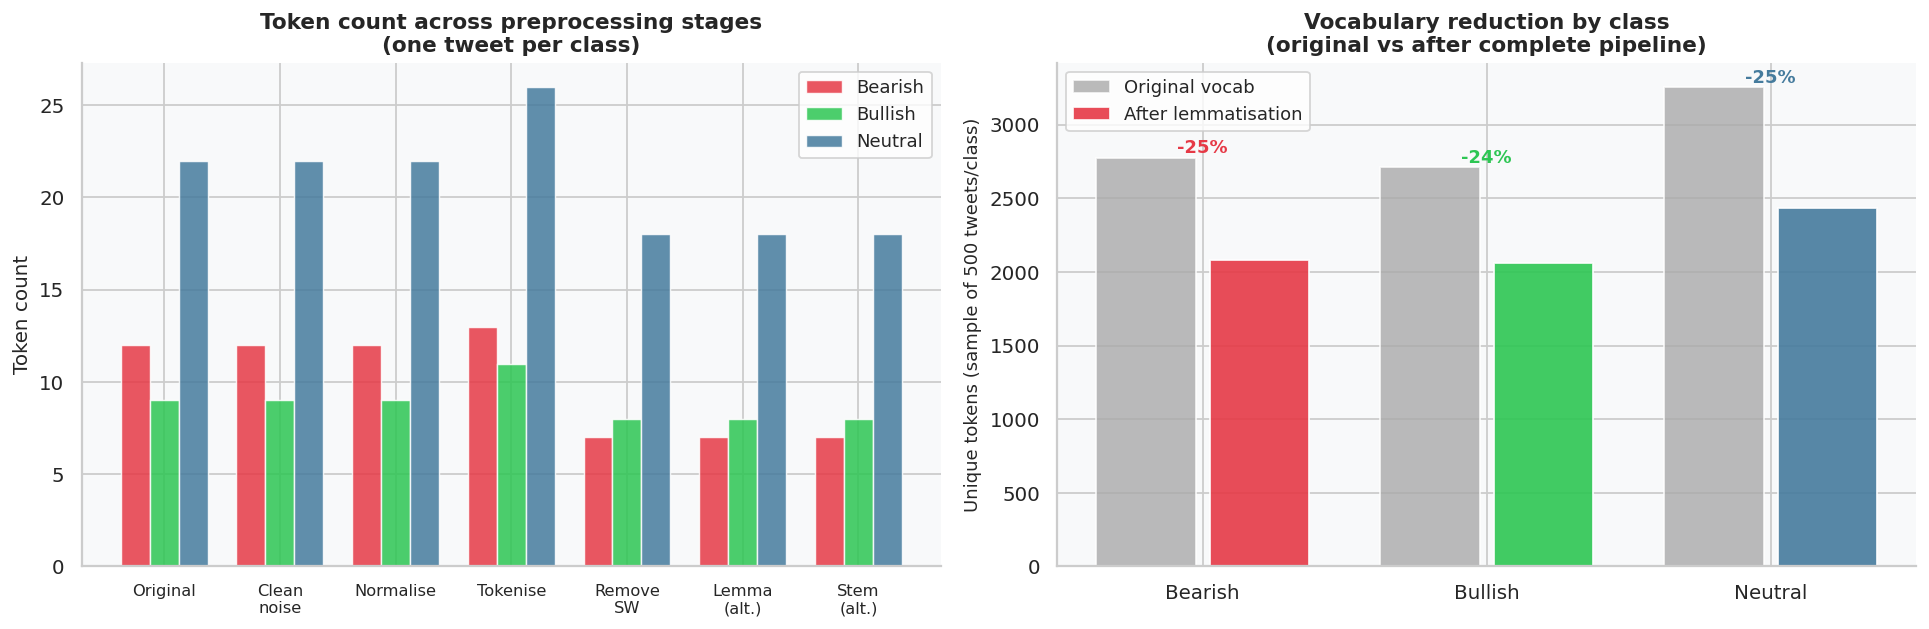

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Left: token counts per stage per class
ax = axes[0]
stage_keys  = ['original', 'cleaned', 'normalized', 'tokenized', 'no_stopwords', 'lemmatized', 'stemmed']
stage_short = ['Original', 'Clean\nnoise', 'Normalise', 'Tokenise', 'Remove\nSW', 'Lemma\n(alt.)', 'Stem\n(alt.)']
colors_cls  = ['#E63946', '#2DC653', '#457B9D']
labels_cls  = ['Bearish', 'Bullish', 'Neutral']

x     = np.arange(len(stage_keys))
width = 0.25

for i, (cls, color, res) in enumerate(results):
    token_counts = [len(res[s].split()) for s in stage_keys]
    ax.bar(x + i * width, token_counts, width, label=labels_cls[i],
           color=colors_cls[i], alpha=0.85, edgecolor='white', linewidth=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(stage_short, fontsize=9)
ax.set_ylabel('Token count', fontsize=11)
ax.set_title('Token count across preprocessing stages\n(one tweet per class)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor('#F8F9FA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: vocabulary reduction on 500 real tweets per class
ax2 = axes[1]
class_reductions = {}
for lbl, name, color in zip([0, 1, 2], labels_cls, colors_cls):
    subset = (
        train[train['label'] == lbl]['text']
        .sample(n=min(500, (train['label'] == lbl).sum()), random_state=42)
        .tolist()
    )
    all_orig = set()
    all_lemma = set()
    for t in subset:
        all_orig.update(t.lower().split())
        cleaned = clean_twitter_noise(t)
        normed  = normalize_text(cleaned)
        tok     = tokenize_tweet(normed)
        no_sw   = remove_stopwords(tok)
        lemma   = lemmatize_tokens(no_sw)
        all_lemma.update(lemma)
    class_reductions[name] = {
        'original':   len(all_orig),
        'lemmatized': len(all_lemma),
        'reduction':  100 * (1 - len(all_lemma) / len(all_orig)),
        'color':      color
    }

x2    = np.arange(len(labels_cls))
orig  = [class_reductions[n]['original']   for n in labels_cls]
lemma = [class_reductions[n]['lemmatized'] for n in labels_cls]

ax2.bar(x2 - 0.2, orig,  0.35, label='Original vocab',      color='#AAAAAA', alpha=0.8, edgecolor='white')
ax2.bar(x2 + 0.2, lemma, 0.35, label='After lemmatisation', color=colors_cls, alpha=0.9, edgecolor='white')

for i, n in enumerate(labels_cls):
    pct = class_reductions[n]['reduction']
    ax2.text(i, max(orig[i], lemma[i]) + 30, f'-{pct:.0f}%',
             ha='center', fontsize=10, fontweight='bold', color=colors_cls[i])

ax2.set_xticks(x2)
ax2.set_xticklabels(labels_cls, fontsize=11)
ax2.set_ylabel('Unique tokens (sample of 500 tweets/class)', fontsize=10)
ax2.set_title('Vocabulary reduction by class\n(original vs after complete pipeline)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_facecolor('#F8F9FA')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
os.makedirs('results/figures', exist_ok=True)
plt.show()


## 3.6. Negation Preservation Check

This is a programmatic sanity check. The EDA showed Bearish has the weakest lexical signal - it relies more on negation patterns than on strong positive/negative sentiment words. Removing `not`, `no`, `never` as generic stopwords would directly harm Bearish recall by inverting or neutralising its core signal.

The implementation in `src/preprocessing.py` handles this through two mechanisms:
1. **Contraction expansion** in `normalize_text`: `don't` -> `do not`, `won't` -> `will not`, `n't` -> ` not` - applied *before* ASCII stripping so the apostrophe is never lost.
2. **`KEEP_NEGATIONS` whitelist** in `remove_stopwords`: `{not, no, never, neither, nor, none}` - these tokens are explicitly excluded from stopword removal.

The cell below verifies both mechanisms work end-to-end on a set of test cases, printing `PASSED` if all negations survive correctly.

In [40]:
negation_tests = [
    ("$SPY is NOT going up, no recovery in sight",           'Bearish'),
    ("I don't see any bullish momentum in $TSLA right now",  'Bearish'),
    ("Never been more bearish on $META after this quarter",  'Bearish'),
    ("$AAPL is absolutely crushing it, very bullish!",       'Bullish'),
    ("Market flat today, neither bullish nor bearish",       'Neutral'),
]


print(f"{'Tweet':<60} {'Class':<10} {'Negations kept':<25} {'OK?'}")
print('-' * 105)
all_ok = True
for tweet, expected_class in negation_tests:
    no_sw = remove_stopwords(tokenize_tweet(normalize_text(clean_twitter_noise(tweet))))
    negs  = [t for t in no_sw if t.lower() in KEEP_NEGATIONS]
    ok    = (expected_class != 'Bearish') or (len(negs) > 0 or 'bearish' in ' '.join(no_sw).lower())
    if not ok:
        all_ok = False
    print(f"{tweet[:58]:<60} {expected_class:<10} {str(negs):<25} {'OK' if ok else 'FAIL'}")

print()
print('Result:', 'PASSED - negations correctly preserved' if all_ok else 'FAILED -- review stopword list')

Tweet                                                        Class      Negations kept            OK?
---------------------------------------------------------------------------------------------------------
$SPY is NOT going up, no recovery in sight                   Bearish    ['not', 'no']             OK
I don't see any bullish momentum in $TSLA right now          Bearish    ['not']                   OK
Never been more bearish on $META after this quarter          Bearish    ['never']                 OK
$AAPL is absolutely crushing it, very bullish!               Bullish    []                        OK
Market flat today, neither bullish nor bearish               Neutral    ['neither', 'nor']        OK

Result: PASSED - negations correctly preserved


## 3.7. Preprocessing Ablation Study

This ablation gives a **preliminary, indicative** answer to the question: *does aggressive preprocessing help for financial tweets?* It uses a fixed probe classifier (Logistic Regression + TF-IDF 10k features) with a leak-free 5-fold CV protocol (vectorizer fitted inside each fold) to isolate the effect of preprocessing from model complexity.

**Scope and limitations:** this ablation is intentionally narrow - LR + TF-IDF is a weak classifier compared to the transformer models evaluated in Section 5. The differences between configs here (F1 range ~0.007) are small and within one standard deviation, so no strong causal claims should be drawn from this alone. The definitive empirical validation is in **Section 6 (Evaluation and Analysis)**, where all model families are compared under the same CV protocol.

What this ablation suggests: aggressive preprocessin (stopwords + lemmatisation/stemming) slightly degrades performance compared to light cleaning, which aligns with the EDA finding that financial vocabulary carries strong discriminative signal.

Preprocessing Ablation (5-fold CV, LR + TF-IDF 10k, vectorizer fitted INSIDE each fold):
                           Config  F1-macro    Std
                       clean only    0.7179 0.0038
           raw (no preprocessing)    0.7152 0.0040
            raw + fix_text (ftfy)    0.7149 0.0032
clean + stopwords + lemmatization    0.7068 0.0045
     clean + stopwords + stemming    0.7062 0.0080



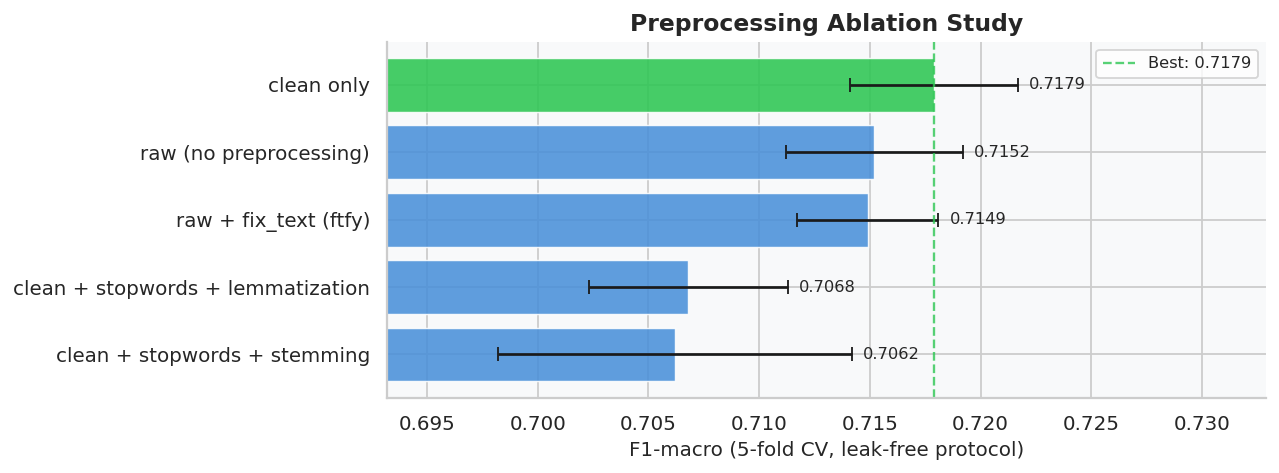

Best config: "clean only"


In [41]:
ablation_df = pd.read_csv('results/tables/preprocessing_ablation.csv')
ablation_df['Std'] = ablation_df['Std'].fillna(0.0)

print('Preprocessing Ablation (5-fold CV, LR + TF-IDF 10k, vectorizer fitted INSIDE each fold):')
print(ablation_df.to_string(index=False))
print()

# colour: best config green, rest blue
best_idx    = ablation_df['F1-macro'].values[::-1].argmax()
colors      = ['#2DC653' if i == best_idx else '#4A90D9'
               for i in range(len(ablation_df))]

fig, ax = plt.subplots(figsize=(10, 3.8), facecolor='white')
bars = ax.barh(
    ablation_df['Config'][::-1],
    ablation_df['F1-macro'][::-1],
    xerr=ablation_df['Std'][::-1],
    capsize=4, color=colors, alpha=0.88,
    edgecolor='white', linewidth=0.8
)

# reference line at best value
best_val = ablation_df['F1-macro'].max()
ax.axvline(best_val, color='#2DC653', linestyle='--',
           linewidth=1.3, alpha=0.8, label=f'Best: {best_val:.4f}')

# value labels
for bar, val, std in zip(bars,
                          ablation_df['F1-macro'][::-1],
                          ablation_df['Std'][::-1]):
    ax.text(bar.get_width() + std + 0.0005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

# tight but honest x-axis
x_min = ablation_df['F1-macro'].min() - ablation_df['Std'].max() - 0.005
x_max = best_val + 0.015
ax.set_xlim(x_min, x_max)

ax.set_xlabel('F1-macro (5-fold CV, leak-free protocol)', fontsize=11)
ax.set_title('Preprocessing Ablation Study', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_facecolor('#F8F9FA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

best_config = ablation_df.loc[ablation_df['F1-macro'].idxmax(), 'Config']
print(f'Best config: "{best_config}"')

---

# 4. Feature Engineering

---

# 5. Classification Models

---

---

# 6. Evaluation and Analysis